In [105]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)

In [106]:
DATA_DIR = Path("../data")

installation = pd.read_csv(DATA_DIR / "installation_base.csv")
telemetry = pd.read_csv(DATA_DIR / "telemetry_daily.csv")

## 1. Load and inspect the raw datasets

Before cleaning anything, we first inspect the raw structure of both files.

The goal of this step is to understand:

- dataset size
- available columns
- obvious formatting inconsistencies
- missing data
- whether the installation and telemetry files can be joined reliably

At this stage, we deliberately avoid transforming the data. The raw inconsistencies are part of the problem we need to understand.

In [107]:
print("Installation base shape:", installation.shape)
print("Telemetry shape:", telemetry.shape)

display(installation.head())
display(telemetry.head())

Installation base shape: (415, 10)
Telemetry shape: (15457, 13)


,reference_number,vendor,customer_name,street_address,contact_phone,postcode_region,commissioning_date,connectivity,service_tier,last_service_visit
0,TH-02085,OEM_A,Holger Thiemann,Erlenring 5,redacted,40,2025-09-24,connected,optimize,NaN
1,th-02232,OEM_B,Ingrid Radtke,Mühlenstraße 94,redacted,12,22.04.2024,unknown,free,2025-02-26
2,02327,OEM_C,Wiebke Hillebrand,Lindenhof 99b,redacted,90,04.07.2024,not_connected,free,2025-08-08
3,TH-02095-1,OEM A,Holger Lindemann,Ostpreußenweg 34,redacted,81,2024-08-11,connected,care_plus,2025-07-02
4,TH-02257,oem-b,Rainer Niehaus,Mühlenstraße 36a,redacted,22,2025-06-14,connected,free,NaN


,reference_number,reading_date,vendor,outdoor_temp_c,flow_temp_c,return_temp_c,dhw_actual_c,electrical_energy_kwh,thermal_energy_kwh,compressor_starts,defrost_cycles,error_code_raw,status_raw
0,TH-02012,2026-06-01,A,17.2,30.8,23.7,47.6,1.81,6.6,8.0,0,NaN,OK
1,TH-02028,2026-06-01,A,17.2,33.4,28.1,46.5,1.86,6.8,11.0,0,NaN,OK
2,TH-02031,2026-06-01,A,17.2,31.8,26.0,51.9,1.22,4.8,11.0,0,NaN,OK
3,TH-02044,2026-06-01,A,17.2,31.7,24.8,49.7,0.98,3.1,8.0,0,NaN,OK
4,TH-02068,2026-06-01,A,17.2,31.2,24.5,50.3,1.97,7.3,11.0,0,NaN,OK


## 2. Profile completeness and uniqueness

Next, we inspect each column for:

- data type
- number of non-null values
- number and percentage of missing values
- number of unique values

This gives us a first view of data quality and helps identify which fields are reliable enough for later analysis.

In [108]:
def profile_df(df):
    return pd.DataFrame({
        "dtype": df.dtypes.astype(str),
        "non_null": df.notna().sum(),
        "missing": df.isna().sum(),
        "missing_pct": (df.isna().mean() * 100).round(1),
        "n_unique": df.nunique(dropna=True),
    })

print("Installation profile")
display(profile_df(installation))

print("Telemetry profile")
display(profile_df(telemetry))

Installation profile


,dtype,non_null,missing,missing_pct,n_unique
reference_number,str,412,3,0.7,412
vendor,str,415,0,0.0,12
customer_name,str,415,0,0.0,313
street_address,str,415,0,0.0,386
contact_phone,str,415,0,0.0,1
postcode_region,int64,415,0,0.0,15
commissioning_date,str,412,3,0.7,369
connectivity,str,415,0,0.0,3
service_tier,str,415,0,0.0,4
last_service_visit,str,288,127,30.6,232


Telemetry profile


,dtype,non_null,missing,missing_pct,n_unique
reference_number,str,15457,0,0.0,808
reading_date,str,15457,0,0.0,60
vendor,str,15457,0,0.0,3
outdoor_temp_c,float64,15457,0,0.0,43
flow_temp_c,float64,6095,9362,60.6,68
return_temp_c,float64,5932,9525,61.6,94
dhw_actual_c,float64,5870,9587,62.0,79
electrical_energy_kwh,float64,15457,0,0.0,6347
thermal_energy_kwh,float64,5689,9768,63.2,185
compressor_starts,float64,11458,3999,25.9,44


## 3. Inspect categorical fields

The case contains multiple source systems and three OEMs, so categorical values may not be standardized.

We inspect vendor labels, connectivity states, and service tiers before defining any normalization rules.

This is important because normalizing too early can hide real inconsistencies in the source data.

In [109]:
print("Installation vendors:")
display(installation["vendor"].value_counts(dropna=False))

print("Telemetry vendors:")
display(telemetry["vendor"].value_counts(dropna=False))

print("Connectivity:")
display(installation["connectivity"].value_counts(dropna=False))

print("Service tiers:")
display(installation["service_tier"].value_counts(dropna=False))

Installation vendors:


vendor
OEM A     45
OEM_B     43
OEM B     42
oem a     38
oem-b     36
OEM_A     33
A         32
OEM_C     32
B         31
oem c     29
OEM_C     28
C         26
Name: count, dtype: int64

Telemetry vendors:


vendor
B    5769
A    5689
C    3999
Name: count, dtype: int64

Connectivity:


connectivity
connected        274
not_connected    110
unknown           31
Name: count, dtype: int64

Service tiers:


service_tier
free         175
optimize     105
care          90
care_plus     45
Name: count, dtype: int64

## 4. Inspect reference-number quality

The `reference_number` field is the key used to identify heating units across the installation and telemetry datasets.

Because the case states that references were written by multiple source systems over several years, we expect formatting defects.

Before creating a canonical identifier, we inspect:

- the number of unique raw references
- common formatting variants
- whether references can be normalized deterministically
- whether normalization could create ambiguous matches

**🟡 Assumption:** a valid canonical heating-unit reference has the form `TH-xxxxx`.

We will not modify the raw field. Any cleaned identifier will be stored in a separate derived column.

In [110]:
print(
    "Raw unique installation references:",
    installation["reference_number"].nunique()
)

print(
    "Raw unique telemetry references:",
    telemetry["reference_number"].nunique()
)

display(
    installation["reference_number"]
    .value_counts(dropna=False)
    .head(30)
)

Raw unique installation references: 412
Raw unique telemetry references: 808


reference_number
NaN            3
TH-02085       1
th-02232       1
02327          1
TH-02095-1     1
  TH-02257     1
TH-02245       1
TH-02065       1
TH-02292       1
  TH-02037     1
th-02101       1
TH-02016-1     1
TH-02250       1
TH-02125       1
TH-02290       1
th-02092       1
TH-02308-1     1
TH 02083       1
th-02011       1
TH-02296-1     1
th-02315       1
TH-02041-1     1
02384          1
TH-02161       1
TH-02163       1
TH-02324       1
TH-02099       1
  TH-02203     1
TH-02108-1     1
TH-02247       1
Name: count, dtype: int64

## 5. Normalize source identifiers

Before joining the installation base to telemetry, we normalize two key dimensions:

1. manufacturer labels
2. heating-unit reference numbers

The raw values are preserved and all cleaned values are stored in separate derived columns.

The installation base contains five classes of reference-number quality:

- 322 already canonical references
- 34 references containing only the five-digit unit number
- 27 formatting variants
- 29 references with an additional `-1` suffix
- 3 records with no reference number

The first three groups can be normalized deterministically to the canonical form `TH-xxxxx`.

The suffix variants require additional investigation because removing the suffix could incorrectly merge two distinct installation records.

The three missing references cannot be linked to a physical unit using the reference field and will therefore remain unresolved.

**🟢 Confirmed:** a canonical `TH-xxxxx` reference represents one heating unit.

**🟡 Assumption:** lowercase, whitespace, missing-prefix, and separator differences are formatting defects rather than different unit identities.

**🧪 Hypothesis requiring validation:** the `-1` suffix may represent duplicate or malformed installation records rather than a distinct physical unit.

In [111]:
def normalize_vendor(value):
    if pd.isna(value):
        return pd.NA

    value = str(value).strip().upper()

    # Remove common prefixes and separators
    value = value.replace("OEM", "")
    value = value.replace("_", "")
    value = value.replace("-", "")
    value = value.replace(" ", "")

    if value in ["A", "B", "C"]:
        return value

    return pd.NA


installation["vendor_canonical"] = installation["vendor"].apply(normalize_vendor)
telemetry["vendor_canonical"] = telemetry["vendor"].apply(normalize_vendor)

print("Installation vendors after normalization:")
display(installation["vendor_canonical"].value_counts(dropna=False))

print("Telemetry vendors after normalization:")
display(telemetry["vendor_canonical"].value_counts(dropna=False))

Installation vendors after normalization:


vendor_canonical
B    152
A    148
C    115
Name: count, dtype: int64

Telemetry vendors after normalization:


vendor_canonical
B    5769
A    5689
C    3999
Name: count, dtype: int64

### 5.1 Normalize OEM labels

The raw installation file contains several textual representations of the same three manufacturers.

For example, OEM A appears as `OEM A`, `OEM_A`, `oem a`, and `A`.

Because telemetry already uses the compact labels `A`, `B`, and `C`, we use those as the canonical OEM values.

This transformation changes formatting only; it does not infer manufacturer identity beyond what is already present in the source field.

In [112]:
import re

def classify_reference(value):
    if pd.isna(value):
        return "missing"

    value = str(value).strip().upper()

    if re.fullmatch(r"TH-\d{5}", value):
        return "canonical"

    if re.fullmatch(r"TH[\s_-]?\d{5}", value):
        return "format_variant"

    if re.fullmatch(r"\d{5}", value):
        return "digits_only"

    if re.fullmatch(r"TH[\s_-]?\d{5}-\d+", value):
        return "suffix_variant"

    return "other"


installation["reference_status"] = (
    installation["reference_number"]
    .apply(classify_reference)
)

display(
    installation["reference_status"]
    .value_counts(dropna=False)
)

reference_status
canonical         322
digits_only        34
suffix_variant     29
format_variant     27
missing             3
Name: count, dtype: int64

### 5.2 Classify reference-number formats

Some reference defects are purely representational:

- lowercase vs uppercase
- missing `TH-` prefix
- spaces instead of hyphens
- leading/trailing whitespace

These can be normalized deterministically.

References containing additional suffixes such as `TH-02095-1` are kept separate for investigation before deciding whether the suffix can safely be removed.

In [113]:
def normalize_reference_safe(value):
    if pd.isna(value):
        return pd.NA

    value = str(value).strip().upper()

    # Extract straightforward 5-digit cases
    if re.fullmatch(r"\d{5}", value):
        return f"TH-{value}"

    match = re.fullmatch(r"TH[\s_-]?(\d{5})", value)
    if match:
        return f"TH-{match.group(1)}"

    return pd.NA


installation["reference_canonical"] = (
    installation["reference_number"]
    .apply(normalize_reference_safe)
)

telemetry["reference_canonical"] = (
    telemetry["reference_number"]
    .apply(normalize_reference_safe)
)

### 5.3 Apply conservative reference normalization

In [114]:
unresolved = installation[
    installation["reference_canonical"].isna()
][
    [
        "reference_number",
        "reference_status",
        "vendor",
        "vendor_canonical",
        "customer_name",
        "street_address"
    ]
]

display(unresolved)

,reference_number,reference_status,vendor,vendor_canonical,customer_name,street_address
3,TH-02095-1,suffix_variant,OEM A,A,Holger Lindemann,Ostpreußenweg 34
10,TH-02016-1,suffix_variant,OEM_A,A,Andreas Niehaus,Lindenhof 35a
15,TH-02308-1,suffix_variant,C,C,Gudrun Hillebrand,Tannenweg 123
18,TH-02296-1,suffix_variant,oem c,C,Gudrun Vollmer,Kirchweg 8a
20,TH-02041-1,suffix_variant,A,A,Ahmet Fährmann,Waldsaum 67b
27,TH-02108-1,suffix_variant,OEM A,A,Ingrid Ahrens,Tannenweg 136
44,NaN,missing,OEM_C,C,Thorsten Gebhardt,Waldsaum 2
54,TH-02199-1,suffix_variant,OEM_B,B,Ingrid Hillebrand,Feldmark 5
70,TH-02358-1,suffix_variant,OEM_C,C,Claudia Brinkmann,Hauptstraße 14
75,TH-02131-1,suffix_variant,oem a,A,Volker Brinkmann,Ahornweg 13a


### 5.4 Investigate unresolved suffix references

After conservative normalization, the remaining unresolved records consist of:

- references with an additional `-1` suffix
- records with no reference number

We do not automatically remove the suffix because doing so could merge two distinct installation records.

Instead, we compare each suffix reference with its potential base reference and check whether that base exists elsewhere in the installation base and/or telemetry.

**🧪 Hypothesis requiring validation:** references ending in `-1` may be duplicate or malformed representations of the same physical heating unit.

In [115]:
suffix_records = installation[
    installation["reference_status"] == "suffix_variant"
].copy()

suffix_records["reference_base_candidate"] = (
    suffix_records["reference_number"]
    .str.upper()
    .str.strip()
    .str.extract(r"TH[\s_-]?(\d{5})", expand=False)
)

suffix_records["reference_base_candidate"] = (
    "TH-" + suffix_records["reference_base_candidate"]
)

display(
    suffix_records[
        [
            "reference_number",
            "reference_base_candidate",
            "vendor_canonical",
            "customer_name",
            "street_address"
        ]
    ]
)

,reference_number,reference_base_candidate,vendor_canonical,customer_name,street_address
3,TH-02095-1,TH-02095,A,Holger Lindemann,Ostpreußenweg 34
10,TH-02016-1,TH-02016,A,Andreas Niehaus,Lindenhof 35a
15,TH-02308-1,TH-02308,C,Gudrun Hillebrand,Tannenweg 123
18,TH-02296-1,TH-02296,C,Gudrun Vollmer,Kirchweg 8a
20,TH-02041-1,TH-02041,A,Ahmet Fährmann,Waldsaum 67b
27,TH-02108-1,TH-02108,A,Ingrid Ahrens,Tannenweg 136
54,TH-02199-1,TH-02199,B,Ingrid Hillebrand,Feldmark 5
70,TH-02358-1,TH-02358,C,Claudia Brinkmann,Hauptstraße 14
75,TH-02131-1,TH-02131,A,Volker Brinkmann,Ahornweg 13a
76,TH-02225-1,TH-02225,B,Jörg Dettmer,Schulstraße 110a


In [116]:
installation_refs = set(
    installation["reference_canonical"]
    .dropna()
    .unique()
)

telemetry_refs = set(
    telemetry["reference_canonical"]
    .dropna()
    .unique()
)

suffix_records["base_exists_in_installation"] = (
    suffix_records["reference_base_candidate"]
    .isin(installation_refs)
)

suffix_records["base_exists_in_telemetry"] = (
    suffix_records["reference_base_candidate"]
    .isin(telemetry_refs)
)

display(
    suffix_records[
        [
            "reference_number",
            "reference_base_candidate",
            "base_exists_in_installation",
            "base_exists_in_telemetry"
        ]
    ]
)

,reference_number,reference_base_candidate,base_exists_in_installation,base_exists_in_telemetry
3,TH-02095-1,TH-02095,False,True
10,TH-02016-1,TH-02016,False,True
15,TH-02308-1,TH-02308,False,True
18,TH-02296-1,TH-02296,False,True
20,TH-02041-1,TH-02041,False,False
27,TH-02108-1,TH-02108,False,False
54,TH-02199-1,TH-02199,True,False
70,TH-02358-1,TH-02358,False,True
75,TH-02131-1,TH-02131,False,False
76,TH-02225-1,TH-02225,False,False


### 5.5 Check for high-confidence duplicate installation records

If a suffix reference points to a base reference that already exists in the installation base, we compare the associated metadata.

A suffix record is considered a high-confidence duplicate only if:

- the base reference exists as another installation record
- the OEM matches
- the customer name matches
- the street address matches

This avoids collapsing records based only on identifier similarity.

In [117]:
base_records = installation[
    installation["reference_canonical"].notna()
][
    [
        "reference_canonical",
        "vendor_canonical",
        "customer_name",
        "street_address"
    ]
].copy()

suffix_check = suffix_records.merge(
    base_records,
    left_on="reference_base_candidate",
    right_on="reference_canonical",
    how="left",
    suffixes=("_suffix", "_base")
)

suffix_check["same_vendor"] = (
    suffix_check["vendor_canonical_suffix"]
    == suffix_check["vendor_canonical_base"]
)

suffix_check["same_customer"] = (
    suffix_check["customer_name_suffix"]
    == suffix_check["customer_name_base"]
)

suffix_check["same_address"] = (
    suffix_check["street_address_suffix"]
    == suffix_check["street_address_base"]
)

suffix_check["high_confidence_duplicate"] = (
    suffix_check["base_exists_in_installation"]
    & suffix_check["same_vendor"]
    & suffix_check["same_customer"]
    & suffix_check["same_address"]
)

display(
    suffix_check[
        [
            "reference_number",
            "reference_base_candidate",
            "base_exists_in_installation",
            "base_exists_in_telemetry",
            "same_vendor",
            "same_customer",
            "same_address",
            "high_confidence_duplicate"
        ]
    ]
)

,reference_number,reference_base_candidate,base_exists_in_installation,base_exists_in_telemetry,same_vendor,same_customer,same_address,high_confidence_duplicate
0,TH-02095-1,TH-02095,False,True,False,False,False,False
1,TH-02016-1,TH-02016,False,True,False,False,False,False
2,TH-02308-1,TH-02308,False,True,False,False,False,False
3,TH-02296-1,TH-02296,False,True,False,False,False,False
4,TH-02041-1,TH-02041,False,False,False,False,False,False
5,TH-02108-1,TH-02108,False,False,False,False,False,False
6,TH-02199-1,TH-02199,True,False,True,True,True,True
7,TH-02358-1,TH-02358,False,True,False,False,False,False
8,TH-02131-1,TH-02131,False,False,False,False,False,False
9,TH-02225-1,TH-02225,False,False,False,False,False,False


In [118]:
print(
    "High-confidence duplicate suffix records:",
    suffix_check["high_confidence_duplicate"].sum()
)

print(
    "Suffix records still unresolved:",
    (~suffix_check["high_confidence_duplicate"]).sum()
)

High-confidence duplicate suffix records: 3
Suffix records still unresolved: 26


### 5.6 Classify suffix-reference resolution

The suffix analysis reveals three distinct cases:

1. **Duplicate installation records**  
   The canonical base reference already exists in the installation base and the OEM, customer, and address all match.

2. **Telemetry-confirmed canonical references**  
   The base reference does not appear elsewhere in the installation base, but it does exist in telemetry.  
   This provides evidence that the installation record's `-1` suffix is a source-system formatting defect and that the record can be linked to the canonical `TH-xxxxx` unit.

3. **Unresolved suffix references**  
   The base reference appears neither in the installation base nor in telemetry.  
   These records are preserved but not force-mapped to a canonical unit.

This distinction separates *duplicate source rows* from *reference reconciliation*.

**🟡 Assumption:** when a suffix-form installation reference such as `TH-02095-1` has a matching canonical `TH-02095` reference in telemetry, both refer to the same physical heating unit.

This assumption is supported by the structure of the supplied data but cannot be independently verified from the available documentation.

In [119]:
suffix_check["resolution_status"] = "suffix_unresolved"

suffix_check.loc[
    suffix_check["base_exists_in_telemetry"],
    "resolution_status"
] = "telemetry_confirmed"

suffix_check.loc[
    suffix_check["high_confidence_duplicate"],
    "resolution_status"
] = "duplicate_of_base"

display(
    suffix_check["resolution_status"]
    .value_counts()
)

resolution_status
telemetry_confirmed    18
suffix_unresolved       8
duplicate_of_base       3
Name: count, dtype: int64

In [120]:
display(
    suffix_check.loc[
        suffix_check["resolution_status"] == "suffix_unresolved",
        [
            "reference_number",
            "reference_base_candidate",
            "vendor_canonical_suffix",
            "customer_name_suffix",
            "street_address_suffix"
        ]
    ]
)

,reference_number,reference_base_candidate,vendor_canonical_suffix,customer_name_suffix,street_address_suffix
4,TH-02041-1,TH-02041,A,Ahmet Fährmann,Waldsaum 67b
5,TH-02108-1,TH-02108,A,Ingrid Ahrens,Tannenweg 136
8,TH-02131-1,TH-02131,A,Volker Brinkmann,Ahornweg 13a
9,TH-02225-1,TH-02225,B,Jörg Dettmer,Schulstraße 110a
10,TH-02117-1,TH-02117,A,Dagmar Zschiesche,Ostpreußenweg 21b
16,TH-02172-1,TH-02172,B,Ingrid Zschiesche,Dorfstraße 2
17,TH-02291-1,TH-02291,C,Ulrike Pfefferle,Feldmark 88
25,TH-02116-1,TH-02116,A,Ingrid Oberkamp,Buchenkamp 1


### 5.7 Create the reconciled unit identifier

We now create a final analytical unit identifier.

- already canonical references retain their canonical value;
- safe formatting variants are normalized;
- telemetry-confirmed suffix variants map to their canonical base reference;
- confirmed duplicate rows map to the same base reference;
- unresolved suffix records and missing references remain without a canonical unit ID.

The raw source reference is preserved separately for auditability.

In [121]:
installation["unit_id"] = installation["reference_canonical"]

# Map resolved suffix records to their base candidate
resolved_suffix_map = suffix_check.loc[
    suffix_check["resolution_status"].isin([
        "telemetry_confirmed",
        "duplicate_of_base"
    ]),
    ["reference_number", "reference_base_candidate"]
]

suffix_map = dict(
    zip(
        resolved_suffix_map["reference_number"],
        resolved_suffix_map["reference_base_candidate"]
    )
)

installation.loc[
    installation["reference_number"].isin(suffix_map),
    "unit_id"
] = (
    installation.loc[
        installation["reference_number"].isin(suffix_map),
        "reference_number"
    ].map(suffix_map)
)

In [122]:
installation["reference_resolution"] = "resolved"

installation.loc[
    installation["reference_status"] == "missing",
    "reference_resolution"
] = "missing_reference"

installation.loc[
    installation["reference_number"].isin(
        suffix_check.loc[
            suffix_check["resolution_status"] == "telemetry_confirmed",
            "reference_number"
        ]
    ),
    "reference_resolution"
] = "telemetry_confirmed_suffix"

installation.loc[
    installation["reference_number"].isin(
        suffix_check.loc[
            suffix_check["resolution_status"] == "duplicate_of_base",
            "reference_number"
        ]
    ),
    "reference_resolution"
] = "duplicate_of_base"

installation.loc[
    installation["reference_number"].isin(
        suffix_check.loc[
            suffix_check["resolution_status"] == "suffix_unresolved",
            "reference_number"
        ]
    ),
    "reference_resolution"
] = "suffix_unresolved"

In [123]:
display(
    installation["reference_resolution"]
    .value_counts(dropna=False)
)

reference_resolution
resolved                      383
telemetry_confirmed_suffix     18
suffix_unresolved               8
missing_reference               3
duplicate_of_base               3
Name: count, dtype: int64

In [124]:
print(
    "Rows with resolved unit_id:",
    installation["unit_id"].notna().sum()
)

print(
    "Unique resolved unit IDs:",
    installation["unit_id"].nunique()
)

print(
    "Rows still unresolved:",
    installation["unit_id"].isna().sum()
)

Rows with resolved unit_id: 404
Unique resolved unit IDs: 392
Rows still unresolved: 11


### 5.8 Audit collisions after reference reconciliation

After reconciliation, 404 installation records have a resolved `unit_id`, but these map to only 392 unique unit IDs.

This means multiple source rows resolve to the same physical-unit identifier.

Before counting the installed base, we inspect these collisions to determine whether they represent:

- duplicate source records for the same installation,
- conflicting records,
- or an error introduced by our normalization logic.

We do not assume that every collision is a duplicate without checking the associated metadata.

In [125]:
unit_id_counts = (
    installation[
        installation["unit_id"].notna()
    ]
    .groupby("unit_id")
    .size()
    .sort_values(ascending=False)
)

colliding_unit_ids = unit_id_counts[
    unit_id_counts > 1
]

print("Unit IDs with multiple installation rows:", len(colliding_unit_ids))
print("Extra resolved rows caused by collisions:", (colliding_unit_ids - 1).sum())

display(colliding_unit_ids)

Unit IDs with multiple installation rows: 12
Extra resolved rows caused by collisions: 12


unit_id
TH-02339    2
TH-02393    2
TH-02122    2
TH-02226    2
TH-02119    2
TH-02085    2
TH-02377    2
TH-02044    2
TH-02199    2
TH-02060    2
TH-02298    2
TH-02002    2
dtype: int64

In [126]:
collision_records = (
    installation[
        installation["unit_id"].isin(colliding_unit_ids.index)
    ][
        [
            "unit_id",
            "reference_number",
            "reference_status",
            "reference_resolution",
            "vendor",
            "vendor_canonical",
            "customer_name",
            "street_address",
            "connectivity",
            "service_tier"
        ]
    ]
    .sort_values(["unit_id", "reference_number"])
)

display(collision_records)

,unit_id,reference_number,reference_status,reference_resolution,vendor,vendor_canonical,customer_name,street_address,connectivity,service_tier
109,TH-02002,TH-02002,canonical,resolved,oem a,A,Holger Ebeling,Buchenkamp 65b,connected,optimize
347,TH-02002,th-02002,canonical,resolved,OEM A,A,Holger Ebeling,Buchenkamp 65b,connected,optimize
164,TH-02044,02044,digits_only,resolved,OEM A,A,Thorsten Gebhardt,Ahornweg 134,connected,free
190,TH-02044,TH-02044-1,suffix_variant,duplicate_of_base,A,A,Thorsten Gebhardt,Ahornweg 134,connected,free
38,TH-02060,TH-02060,canonical,resolved,OEM_A,A,Claudia Ahrens,Tannenweg 137,unknown,free
413,TH-02060,TH-02060,canonical,resolved,OEM_A,A,Claudia Ahrens,Tannenweg 137,not_connected,free
0,TH-02085,TH-02085,canonical,resolved,OEM_A,A,Holger Thiemann,Erlenring 5,connected,optimize
333,TH-02085,TH-02085-1,suffix_variant,duplicate_of_base,oem a,A,Holger Thiemann,Erlenring 5,connected,optimize
241,TH-02119,TH-02119,canonical,resolved,A,A,Thorsten Niehaus,Schulstraße 68,unknown,optimize
179,TH-02119,TH-02119,canonical,resolved,OEM A,A,Thorsten Niehaus,Schulstraße 68,not_connected,optimize


In [127]:
collision_summary = (
    collision_records
    .groupby("unit_id")
    .agg(
        source_rows=("reference_number", "size"),
        raw_references=("reference_number", lambda x: list(x)),
        vendors=("vendor_canonical", lambda x: x.dropna().nunique()),
        customers=("customer_name", lambda x: x.dropna().nunique()),
        addresses=("street_address", lambda x: x.dropna().nunique()),
        connectivity_values=("connectivity", lambda x: x.dropna().nunique()),
        service_tiers=("service_tier", lambda x: x.dropna().nunique())
    )
)

display(collision_summary)

,source_rows,raw_references,vendors,customers,addresses,connectivity_values,service_tiers
unit_id,,,,,,,
TH-02002,2,"[ TH-02002 , th-02002]",1,1,1,1,1
TH-02044,2,"[02044, TH-02044-1]",1,1,1,1,1
TH-02060,2,"[ TH-02060 , TH-02060]",1,1,1,2,1
TH-02085,2,"[TH-02085, TH-02085-1]",1,1,1,1,1
TH-02119,2,"[ TH-02119 , TH-02119]",1,1,1,2,1
TH-02122,2,"[TH-02122, th-02122]",1,1,1,1,1
TH-02199,2,"[TH-02199, TH-02199-1]",1,1,1,2,1
TH-02226,2,"[TH-02226, th-02226]",1,1,1,1,1
TH-02298,2,"[ TH-02298 , TH 02298]",1,1,1,1,1


In [128]:
collision_summary["metadata_consistent"] = (
    (collision_summary["vendors"] <= 1)
    & (collision_summary["customers"] <= 1)
    & (collision_summary["addresses"] <= 1)
)

display(collision_summary)

,source_rows,raw_references,vendors,customers,addresses,connectivity_values,service_tiers,metadata_consistent
unit_id,,,,,,,,
TH-02002,2,"[ TH-02002 , th-02002]",1,1,1,1,1,True
TH-02044,2,"[02044, TH-02044-1]",1,1,1,1,1,True
TH-02060,2,"[ TH-02060 , TH-02060]",1,1,1,2,1,True
TH-02085,2,"[TH-02085, TH-02085-1]",1,1,1,1,1,True
TH-02119,2,"[ TH-02119 , TH-02119]",1,1,1,2,1,True
TH-02122,2,"[TH-02122, th-02122]",1,1,1,1,1,True
TH-02199,2,"[TH-02199, TH-02199-1]",1,1,1,2,1,True
TH-02226,2,"[TH-02226, th-02226]",1,1,1,1,1,True
TH-02298,2,"[ TH-02298 , TH 02298]",1,1,1,1,1,True


### 5.9 Reconciliation conclusion

The collision audit identified 12 canonical unit IDs that appear more than once in the installation source.

For all 12, the vendor, customer, and address match across records. This provides strong evidence that these are duplicate source records for the same physical heating unit rather than distinct installations.

Three duplicated units contain conflicting `connectivity` values. These conflicts are preserved as data-quality issues, but they do not change the unit identity because the core identifying metadata remains consistent.

After reconciliation:

- 404 source rows can be linked to a canonical unit ID
- these represent 392 unique resolved units
- 11 installation records remain unresolved:
  - 8 suffix references with no corroborating base reference
  - 3 records with no reference number

**🟡 Assumption:** matching canonical reference, vendor, customer, and address is sufficient evidence that duplicate source rows represent the same physical heating unit.

## 6. Determine the installed base

The installation file contains 415 source records, but source-row count is not equivalent to physical-unit count.

After identifier reconciliation and duplicate analysis, we distinguish between:

- **resolved units:** records that can be linked confidently to a canonical `TH-xxxxx` identifier
- **unresolved installation records:** records that appear to represent installations but cannot be assigned confidently to a canonical identifier

This distinction prevents us from either double-counting duplicates or silently discarding unresolved records.

In [129]:
resolved_unique_units = installation["unit_id"].nunique()

unresolved_records = installation[
    installation["unit_id"].isna()
]

missing_reference_records = unresolved_records[
    unresolved_records["reference_status"] == "missing"
]

unresolved_suffix_records = unresolved_records[
    unresolved_records["reference_status"] == "suffix_variant"
]

print("Source installation rows:", len(installation))
print("Resolved unique units:", resolved_unique_units)
print("Unresolved installation records:", len(unresolved_records))
print("  - Missing references:", len(missing_reference_records))
print("  - Unresolved suffix references:", len(unresolved_suffix_records))

Source installation rows: 415
Resolved unique units: 392
Unresolved installation records: 11
  - Missing references: 3
  - Unresolved suffix references: 8


In [130]:
display(
    unresolved_records[
        [
            "reference_number",
            "reference_status",
            "vendor_canonical",
            "customer_name",
            "street_address",
            "connectivity",
            "service_tier"
        ]
    ]
)

,reference_number,reference_status,vendor_canonical,customer_name,street_address,connectivity,service_tier
20,TH-02041-1,suffix_variant,A,Ahmet Fährmann,Waldsaum 67b,not_connected,care
27,TH-02108-1,suffix_variant,A,Ingrid Ahrens,Tannenweg 136,not_connected,optimize
44,NaN,missing,C,Thorsten Gebhardt,Waldsaum 2,unknown,free
75,TH-02131-1,suffix_variant,A,Volker Brinkmann,Ahornweg 13a,not_connected,care_plus
76,TH-02225-1,suffix_variant,B,Jörg Dettmer,Schulstraße 110a,unknown,free
110,TH-02117-1,suffix_variant,A,Dagmar Zschiesche,Ostpreußenweg 21b,not_connected,free
176,NaN,missing,A,Thorsten Thiemann,Rosenkamp 56b,unknown,free
230,TH-02172-1,suffix_variant,B,Ingrid Zschiesche,Dorfstraße 2,not_connected,care_plus
244,TH-02291-1,suffix_variant,C,Ulrike Pfefferle,Feldmark 88,not_connected,care_plus
247,NaN,missing,A,Dagmar Dettmer,Pappelweg 45,unknown,free


### 6.1 Check unresolved records against customer and address metadata

The remaining unresolved records may still correspond to another installation record even though their reference number cannot be reconciled directly.

As a secondary identity check, we compare each unresolved record against the rest of the installation base using:

- customer name
- street address
- vendor

We treat this only as supporting evidence. A metadata match does not override the canonical reference logic unless the match is unambiguous.

In [131]:
unresolved_matches = []

for idx, row in unresolved_records.iterrows():

    matches = installation[
        (installation.index != idx)
        & (installation["customer_name"] == row["customer_name"])
        & (installation["street_address"] == row["street_address"])
        & (installation["vendor_canonical"] == row["vendor_canonical"])
    ]

    unresolved_matches.append({
        "source_index": idx,
        "reference_number": row["reference_number"],
        "customer_name": row["customer_name"],
        "street_address": row["street_address"],
        "vendor_canonical": row["vendor_canonical"],
        "matching_records": len(matches),
        "matching_unit_ids": list(matches["unit_id"].dropna().unique()),
        "matching_raw_refs": list(matches["reference_number"].dropna().unique())
    })

unresolved_match_df = pd.DataFrame(unresolved_matches)

display(unresolved_match_df)

,source_index,reference_number,customer_name,street_address,vendor_canonical,matching_records,matching_unit_ids,matching_raw_refs
0,20,TH-02041-1,Ahmet Fährmann,Waldsaum 67b,A,0,[],[]
1,27,TH-02108-1,Ingrid Ahrens,Tannenweg 136,A,0,[],[]
2,44,NaN,Thorsten Gebhardt,Waldsaum 2,C,0,[],[]
3,75,TH-02131-1,Volker Brinkmann,Ahornweg 13a,A,0,[],[]
4,76,TH-02225-1,Jörg Dettmer,Schulstraße 110a,B,0,[],[]
5,110,TH-02117-1,Dagmar Zschiesche,Ostpreußenweg 21b,A,0,[],[]
6,176,NaN,Thorsten Thiemann,Rosenkamp 56b,A,0,[],[]
7,230,TH-02172-1,Ingrid Zschiesche,Dorfstraße 2,B,0,[],[]
8,244,TH-02291-1,Ulrike Pfefferle,Feldmark 88,C,0,[],[]
9,247,NaN,Dagmar Dettmer,Pappelweg 45,A,0,[],[]


In [132]:
print(
    "Unresolved records with at least one exact metadata match:",
    (unresolved_match_df["matching_records"] > 0).sum()
)

print(
    "Unresolved records with no exact metadata match:",
    (unresolved_match_df["matching_records"] == 0).sum()
)

Unresolved records with at least one exact metadata match: 0
Unresolved records with no exact metadata match: 11


### 6.2 Investigate partial metadata matches

If an unresolved record has no exact match, we check customer name and street address separately.

These are exploratory checks only because either field can occur more than once in the synthetic dataset.

In [133]:
partial_match_results = []

for idx, row in unresolved_records.iterrows():

    same_customer = installation[
        (installation.index != idx)
        & (installation["customer_name"] == row["customer_name"])
    ]

    same_address = installation[
        (installation.index != idx)
        & (installation["street_address"] == row["street_address"])
    ]

    partial_match_results.append({
        "source_index": idx,
        "reference_number": row["reference_number"],
        "customer_name": row["customer_name"],
        "street_address": row["street_address"],
        "same_customer_count": len(same_customer),
        "same_address_count": len(same_address),
        "customer_match_unit_ids": list(
            same_customer["unit_id"].dropna().unique()
        ),
        "address_match_unit_ids": list(
            same_address["unit_id"].dropna().unique()
        )
    })

partial_match_df = pd.DataFrame(partial_match_results)

display(partial_match_df)

,source_index,reference_number,customer_name,street_address,same_customer_count,same_address_count,customer_match_unit_ids,address_match_unit_ids
0,20,TH-02041-1,Ahmet Fährmann,Waldsaum 67b,2,0,"[TH-02006, TH-02013]",[]
1,27,TH-02108-1,Ingrid Ahrens,Tannenweg 136,0,0,[],[]
2,44,NaN,Thorsten Gebhardt,Waldsaum 2,2,1,[TH-02044],[TH-02248]
3,75,TH-02131-1,Volker Brinkmann,Ahornweg 13a,0,0,[],[]
4,76,TH-02225-1,Jörg Dettmer,Schulstraße 110a,0,1,[],[TH-02215]
5,110,TH-02117-1,Dagmar Zschiesche,Ostpreußenweg 21b,0,0,[],[]
6,176,NaN,Thorsten Thiemann,Rosenkamp 56b,0,0,[],[]
7,230,TH-02172-1,Ingrid Zschiesche,Dorfstraße 2,0,0,[],[]
8,244,TH-02291-1,Ulrike Pfefferle,Feldmark 88,0,0,[],[]
9,247,NaN,Dagmar Dettmer,Pappelweg 45,0,0,[],[]


### 6.3 Do not use customer metadata as a unit identifier

We tested whether the 11 unresolved installation records could be reconciled using customer name, street address, and vendor.

No unresolved record had an exact match on all three fields.

Partial matching produced several ambiguous cases:

- customer names occur across multiple unit IDs
- street addresses can also occur against other unit IDs
- in at least one case, the customer name and address point toward different existing units

This demonstrates that customer and address metadata are not reliable identifiers for reconciliation in this dataset.

We therefore do not use customer name or address to assign a canonical unit ID.

The installation reference remains the primary identity key.

In [134]:
def normalize_reference(value):
    if pd.isna(value):
        return pd.NA

    value = str(value).strip().upper()

    # Digits only: 02044
    if re.fullmatch(r"\d{5}", value):
        return f"TH-{value}"

    # Canonical / formatting variants
    match = re.fullmatch(r"TH[\s_-]?(\d{5})", value)
    if match:
        return f"TH-{match.group(1)}"

    # Repeated suffix pattern observed in the source
    match = re.fullmatch(r"TH[\s_-]?(\d{5})-1", value)
    if match:
        return f"TH-{match.group(1)}"

    return pd.NA

In [135]:
installation["unit_id"] = (
    installation["reference_number"]
    .apply(normalize_reference)
)

In [136]:
print("Resolved rows:", installation["unit_id"].notna().sum())
print("Unique unit IDs:", installation["unit_id"].nunique())
print("Unresolved rows:", installation["unit_id"].isna().sum())

Resolved rows: 412
Unique unit IDs: 400
Unresolved rows: 3


## 6. Installed-base reconciliation result

The source installation file contains 415 rows.

After normalizing reference formats, including the recurring `TH-xxxxx-1` suffix pattern:

- 412 rows have a resolvable canonical unit ID
- these represent 400 unique canonical heat-pump units
- 12 rows are duplicate source records that resolve to an already identified unit
- 3 installation records have no reference number and therefore cannot be linked confidently to a canonical unit ID

**🟢 Confirmed:** 400 unique heat pumps can be identified confidently from canonical references.

**🟡 Assumption:** the three reference-less installation records may represent additional physical installations, but the supplied data does not allow them to be identified reliably.

For product analysis, the 400 resolved units form the canonical installed base. The three unresolved records are retained separately as data-quality exceptions rather than force-matched.

## 7. Connectivity and telemetry coverage

The installation file indicates whether a unit is expected to send data, but this does not necessarily mean telemetry is actually available.

For the service cockpit, we need to distinguish between:

- units expected to be connected
- units actually reporting telemetry
- units marked connected but with no telemetry
- units not marked connected but still appearing in telemetry

This distinction is important because "no telemetry" and "healthy telemetry" must never be shown as the same state.

In [137]:
telemetry["unit_id"] = (
    telemetry["reference_number"]
    .apply(normalize_reference)
)

print("Telemetry rows:", len(telemetry))
print("Resolved telemetry rows:", telemetry["unit_id"].notna().sum())
print("Unique telemetry unit IDs:", telemetry["unit_id"].nunique())
print("Unresolved telemetry rows:", telemetry["unit_id"].isna().sum())

Telemetry rows: 15457
Resolved telemetry rows: 15457
Unique telemetry unit IDs: 273
Unresolved telemetry rows: 0


In [138]:
installation_unit_ids = set(
    installation["unit_id"]
    .dropna()
    .unique()
)

telemetry_unit_ids = set(
    telemetry["unit_id"]
    .dropna()
    .unique()
)

telemetry_only_units = telemetry_unit_ids - installation_unit_ids
installation_only_units = installation_unit_ids - telemetry_unit_ids

print("Units in telemetry but not installation base:", len(telemetry_only_units))
print("Units in installation base but not telemetry:", len(installation_only_units))

Units in telemetry but not installation base: 5
Units in installation base but not telemetry: 132


### 7.1 Build the canonical unit table

The raw installation file contains duplicate source rows, so we create a one-row-per-unit analytical table.

This table becomes the base for service-cockpit analysis.

Where duplicate source records disagree on secondary fields such as connectivity, the disagreement is preserved separately as a data-quality issue rather than silently overwritten.

In [139]:
unit_base = (
    installation[
        installation["unit_id"].notna()
    ]
    .sort_values("unit_id")
    .drop_duplicates(
        subset="unit_id",
        keep="first"
    )
    .copy()
)

print("Canonical unit rows:", len(unit_base))

Canonical unit rows: 400


In [140]:
connectivity_conflicts = (
    installation[
        installation["unit_id"].notna()
    ]
    .groupby("unit_id")["connectivity"]
    .nunique()
)

connectivity_conflicts = connectivity_conflicts[
    connectivity_conflicts > 1
]

print(
    "Units with conflicting connectivity values:",
    len(connectivity_conflicts)
)

display(connectivity_conflicts)

Units with conflicting connectivity values: 3


unit_id
TH-02060    2
TH-02119    2
TH-02199    2
Name: connectivity, dtype: int64

In [141]:
unit_base["connectivity_conflict"] = (
    unit_base["unit_id"]
    .isin(connectivity_conflicts.index)
) # Units flagged

In [142]:
telemetry["reading_date"] = pd.to_datetime(
    telemetry["reading_date"],
    errors="coerce"
)

print(
    "Telemetry date range:",
    telemetry["reading_date"].min(),
    "to",
    telemetry["reading_date"].max()
)

Telemetry date range: 2026-06-01 00:00:00 to 2026-07-30 00:00:00


In [143]:
telemetry_coverage = (
    telemetry[
        telemetry["unit_id"].notna()
    ]
    .groupby("unit_id")
    .agg(
        telemetry_rows=("reading_date", "size"),
        first_reading=("reading_date", "min"),
        latest_reading=("reading_date", "max"),
        telemetry_days=("reading_date", "nunique")
    )
    .reset_index()
)

display(telemetry_coverage.head())

,unit_id,telemetry_rows,first_reading,latest_reading,telemetry_days
0,TH-02001,59,2026-06-01,2026-07-30,59
1,TH-02002,59,2026-06-01,2026-07-30,59
2,TH-02004,60,2026-06-01,2026-07-30,60
3,TH-02005,59,2026-06-01,2026-07-30,59
4,TH-02006,60,2026-06-01,2026-07-30,60


In [144]:
units = unit_base.merge(
    telemetry_coverage,
    on="unit_id",
    how="left"
)

units["has_telemetry"] = (
    units["telemetry_rows"]
    .fillna(0)
    .gt(0)
)

display(
    pd.crosstab(
        units["connectivity"],
        units["has_telemetry"],
        margins=True
    )
)

has_telemetry,False,True,All
connectivity,,,
connected,0,265,265
not_connected,105,3,108
unknown,27,0,27
All,132,268,400


### 7.3 Compare connectivity coverage by OEM

Because the three manufacturers expose data through different technical paths, connectivity and telemetry completeness may differ materially by OEM.

We therefore analyze actual reporting coverage by manufacturer rather than assuming a uniform connected base.

In [145]:
coverage_by_vendor = (
    units
    .groupby("vendor_canonical")
    .agg(
        units=("unit_id", "nunique"),
        expected_connected=(
            "connectivity",
            lambda x: (x == "connected").sum()
        ),
        actually_reporting=(
            "has_telemetry",
            "sum"
        )
    )
)

coverage_by_vendor["reporting_pct"] = (
    coverage_by_vendor["actually_reporting"]
    / coverage_by_vendor["units"]
    * 100
).round(1)

display(coverage_by_vendor)

,units,expected_connected,actually_reporting,reporting_pct
vendor_canonical,,,,
A,140,95,97,69.3
B,150,98,98,65.3
C,110,72,73,66.4


### 7.4 Initial connectivity findings

Of the 400 resolved heat-pump units:

- 268 have at least one telemetry record
- 132 have no telemetry in the supplied period
- all 265 units marked `connected` have telemetry
- 3 units marked `not_connected` nevertheless appear in telemetry
- none of the 27 units with `unknown` connectivity appear in telemetry

Telemetry availability is relatively similar across OEMs:

- OEM A: 69.3% of installed units
- OEM B: 65.3%
- OEM C: 66.4%

This suggests that the main issue in this extract is not widespread failure among units explicitly marked as connected.

However, `has_telemetry` only tells us whether a unit reported at least once during the two-month dataset. It does not tell us whether the data is complete or recent enough to support service decisions.

The next step is therefore to analyze telemetry freshness and continuity.

In [146]:
unexpected_reporting = units[
    (units["connectivity"] == "not_connected")
    & (units["has_telemetry"])
]

display(
    unexpected_reporting[
        [
            "unit_id",
            "vendor_canonical",
            "customer_name",
            "connectivity",
            "first_reading",
            "latest_reading",
            "telemetry_days"
        ]
    ]
)

,unit_id,vendor_canonical,customer_name,connectivity,first_reading,latest_reading,telemetry_days
35,TH-02036,A,Elke Jansen,not_connected,2026-06-01,2026-07-30,58.0
53,TH-02054,A,Thorsten Grabowski,not_connected,2026-06-01,2026-07-30,60.0
333,TH-02334,C,Lothar Vollmer,not_connected,2026-06-01,2026-07-30,54.0


## 8. Telemetry freshness and continuity

Having telemetry at some point in the dataset is not enough for service use.

A technician needs to know:

- when the unit last reported
- whether reporting has been continuous
- whether recent values are based on complete or partial data

The supplied telemetry covers 1 June to 30 July 2026, so we use the final date in the dataset as the reference point for freshness rather than the current calendar date.

In [154]:
dataset_end = telemetry["reading_date"].max()

units["days_since_last_reading"] = (
    dataset_end - units["latest_reading"]
).dt.days

display(
    units[
        units["has_telemetry"]
    ]["days_since_last_reading"]
    .describe()
)

count    268.000000
mean       0.134328
std        1.062053
min        0.000000
25%        0.000000
50%        0.000000
75%        0.000000
max       10.000000
Name: days_since_last_reading, dtype: float64

In [155]:
display(
    units[
        units["has_telemetry"]
    ]["days_since_last_reading"]
    .value_counts()
    .sort_index()
)

days_since_last_reading
0.0     259
1.0       6
10.0      3
Name: count, dtype: int64

### 8.1 Measure reporting completeness across the dataset

The telemetry extract covers a fixed reporting window.

For each unit with telemetry, we calculate:

- the number of distinct reporting days
- the percentage of the full dataset period covered
- the latest available reading

This gives us a first view of completeness before looking at gaps or vendor-specific reporting patterns.

In [156]:
dataset_start = telemetry["reading_date"].min()
dataset_end = telemetry["reading_date"].max()

expected_days = (dataset_end - dataset_start).days + 1

print("Dataset start:", dataset_start)
print("Dataset end:", dataset_end)
print("Possible reporting days:", expected_days)

Dataset start: 2026-06-01 00:00:00
Dataset end: 2026-07-30 00:00:00
Possible reporting days: 60


In [157]:
units["telemetry_coverage_pct"] = (
    units["telemetry_days"]
    / expected_days
    * 100
).round(1)

display(
    units[
        units["has_telemetry"]
    ]["telemetry_days"]
    .describe()
)

count    268.000000
mean      57.171642
std        3.000689
min       44.000000
25%       54.000000
50%       59.000000
75%       59.000000
max       60.000000
Name: telemetry_days, dtype: float64

In [158]:
coverage_completeness_by_vendor = (
    units[
        units["has_telemetry"]
    ]
    .groupby("vendor_canonical")
    .agg(
        reporting_units=("unit_id", "nunique"),
        median_days=("telemetry_days", "median"),
        min_days=("telemetry_days", "min"),
        max_days=("telemetry_days", "max"),
        median_coverage_pct=("telemetry_coverage_pct", "median"),
        median_days_stale=("days_since_last_reading", "median")
    )
)

display(coverage_completeness_by_vendor)

,reporting_units,median_days,min_days,max_days,median_coverage_pct,median_days_stale
vendor_canonical,,,,,,
A,97,59.0,47.0,60.0,98.3,0.0
B,98,59.0,49.0,60.0,98.3,0.0
C,73,53.0,44.0,54.0,88.3,0.0


### 8.2 Build the reporting-unit analysis table

For units with telemetry, we create a derived table that captures:

- when reporting started
- when reporting stopped
- how many days were observed
- whether there are gaps within the observed reporting window
- how continuous the telemetry is once reporting begins

This allows us to distinguish late starts, early stops, and intermittent reporting.

### 8.3 Freshness and continuity findings

Telemetry freshness at the end of the supplied period is generally strong:

- 259 of 268 reporting units have a reading on the final dataset date
- 6 units are one day behind
- 3 units are ten days behind

This means that stale telemetry is not a widespread issue in the supplied extract, although the three units that stopped reporting ten days early may still be operationally relevant.

Reporting continuity differs by OEM:

- OEM A reports for a median of 59 out of 60 days
- OEM B reports for a median of 59 out of 60 days
- OEM C reports for a median of 53 out of 60 days
- the maximum observed coverage for OEM C is only 54 days

This suggests a systematic OEM-specific pattern rather than isolated missing readings.

**🧪 Hypothesis requiring validation:** OEM C telemetry may begin later in the supplied period because of its source integration or extraction process, rather than because individual units stopped reporting.

In [159]:
reporting_units = units[
    units["has_telemetry"]
].copy()

reporting_units["days_from_start_to_first"] = (
    reporting_units["first_reading"] - dataset_start
).dt.days

reporting_units["days_from_last_to_end"] = (
    dataset_end - reporting_units["latest_reading"]
).dt.days

reporting_units["observed_window_days"] = (
    reporting_units["latest_reading"]
    - reporting_units["first_reading"]
).dt.days + 1

reporting_units["missing_days_within_window"] = (
    reporting_units["observed_window_days"]
    - reporting_units["telemetry_days"]
)

reporting_units["continuity_pct"] = (
    reporting_units["telemetry_days"]
    / reporting_units["observed_window_days"]
    * 100
).round(1)

print("Reporting units:", len(reporting_units))
display(reporting_units.head())

Reporting units: 268


,reference_number,vendor,customer_name,street_address,contact_phone,postcode_region,commissioning_date,connectivity,service_tier,last_service_visit,vendor_canonical,reference_status,reference_canonical,unit_id,reference_resolution,connectivity_conflict,telemetry_rows,first_reading,latest_reading,telemetry_days,has_telemetry,days_since_last_reading,telemetry_coverage_pct,days_from_start_to_first,days_from_last_to_end,observed_window_days,missing_days_within_window,continuity_pct
0,TH-02001-1,oem a,Manuela Niehaus,Gartenstraße 46,redacted,81,2024-11-26,connected,optimize,2025-02-07,A,suffix_variant,NaN,TH-02001,telemetry_confirmed_suffix,False,59.0,2026-06-01,2026-07-30,59.0,True,0.0,98.3,0,0,60,1.0,98.3
1,TH-02002,oem a,Holger Ebeling,Buchenkamp 65b,redacted,10,31.01.2026,connected,optimize,NaN,A,canonical,TH-02002,TH-02002,resolved,False,59.0,2026-06-01,2026-07-30,59.0,True,0.0,98.3,0,0,60,1.0,98.3
3,02004,OEM A,Rainer Gebhardt,Ostpreußenweg 56,redacted,13,2025-07-07,connected,free,2026-02-01,A,digits_only,TH-02004,TH-02004,resolved,False,60.0,2026-06-01,2026-07-30,60.0,True,0.0,100.0,0,0,60,0.0,100.0
4,TH-02005,oem a,Gerhard Niehaus,Gartenstraße 39,redacted,70,2025-09-12,connected,free,2025-09-23,A,canonical,TH-02005,TH-02005,resolved,False,59.0,2026-06-01,2026-07-30,59.0,True,0.0,98.3,0,0,60,1.0,98.3
5,TH 02006,oem a,Ahmet Fährmann,Tannenweg 87,redacted,12,2023-05-19,connected,optimize,2025-08-10,A,format_variant,TH-02006,TH-02006,resolved,False,60.0,2026-06-01,2026-07-30,60.0,True,0.0,100.0,0,0,60,0.0,100.0


### 8.3 Check whether reporting windows differ by OEM

OEM C has fewer reporting days than OEM A and B.

Before interpreting this as poorer telemetry quality, we check whether OEM C simply begins reporting later in the extract.

This helps distinguish a source-window effect from genuine unit-level missing data.

In [160]:
first_reading_by_vendor = (
    reporting_units
    .groupby("vendor_canonical")
    .agg(
        earliest_first_reading=("first_reading", "min"),
        median_first_reading=("first_reading", "median"),
        latest_first_reading=("first_reading", "max"),
        earliest_last_reading=("latest_reading", "min"),
        latest_last_reading=("latest_reading", "max")
    )
)

display(first_reading_by_vendor)

,earliest_first_reading,median_first_reading,latest_first_reading,earliest_last_reading,latest_last_reading
vendor_canonical,,,,,
A,2026-06-01,2026-06-01,2026-06-02,2026-07-20,2026-07-30
B,2026-06-01,2026-06-01,2026-06-01,2026-07-20,2026-07-30
C,2026-06-01,2026-06-01,2026-06-01,2026-07-20,2026-07-30


In [161]:
display(
    reporting_units
    .groupby([
        "vendor_canonical",
        "first_reading"
    ])
    .size()
    .to_frame("units")
)

units
vendor_canonical first_reading       
A                2026-06-01        95
                 2026-06-02         2
B                2026-06-01        98
C                2026-06-01        73

### 8.4 Inspect units that stopped reporting before the end of the dataset

Most reporting units are fresh at the end of the extract.

We therefore inspect the small number of units whose latest reading is several days behind the dataset end.

The goal is to determine whether this looks like:

- an individual unit issue
- a vendor-wide source interruption
- or a small number of isolated telemetry gaps

In [162]:
stale_units = reporting_units[
    reporting_units["days_from_last_to_end"] >= 2
].sort_values(
    "days_from_last_to_end",
    ascending=False
)

display(
    stale_units[
        [
            "unit_id",
            "vendor_canonical",
            "connectivity",
            "telemetry_days",
            "first_reading",
            "latest_reading",
            "days_from_last_to_end",
            "missing_days_within_window",
            "continuity_pct"
        ]
    ]
)

,unit_id,vendor_canonical,connectivity,telemetry_days,first_reading,latest_reading,days_from_last_to_end,missing_days_within_window,continuity_pct
22,TH-02023,A,connected,47.0,2026-06-01,2026-07-20,10,3.0,94.0
279,TH-02280,B,connected,49.0,2026-06-01,2026-07-20,10,1.0,98.0
303,TH-02304,C,connected,44.0,2026-06-01,2026-07-20,10,6.0,88.0


### 8.5 Compare telemetry continuity by OEM

Full-period coverage can be misleading if an OEM begins reporting later in the extract.

We therefore compare:

- coverage across the full dataset period
- continuity within each unit's own observed reporting window

This separates source-window effects from actual gaps in reporting.

In [163]:
continuity_by_vendor = (
    reporting_units
    .groupby("vendor_canonical")
    .agg(
        reporting_units=("unit_id", "nunique"),
        median_full_period_coverage=("telemetry_coverage_pct", "median"),
        median_observed_continuity=("continuity_pct", "median"),
        min_observed_continuity=("continuity_pct", "min"),
        median_days_stale=("days_from_last_to_end", "median")
    )
)

display(continuity_by_vendor)

,reporting_units,median_full_period_coverage,median_observed_continuity,min_observed_continuity,median_days_stale
vendor_canonical,,,,,
A,97,98.3,98.3,91.7,0.0
B,98,98.3,98.3,93.3,0.0
C,73,88.3,88.3,83.3,0.0


### 8.6 Data-model caveat: duplicate source attributes

The canonical unit table currently keeps the first source record when multiple installation rows resolve to the same `unit_id`.

This is sufficient for exploratory analysis of stable identifying fields such as customer, address, and OEM, which were confirmed to match across duplicate records.

However, some duplicate records disagree on mutable attributes such as `connectivity`.

Therefore, secondary installation attributes should not be considered authoritative simply because they appear in the retained row.

For the prototype, conflicting source attributes should either be:

- explicitly marked as conflicting, or
- resolved using a defined source-of-truth rule once one is available.

We do not silently interpret the first source row as authoritative.

## 9. Analyze telemetry field coverage by OEM

The three manufacturers expose different fields, semantics, and levels of completeness.

Before using telemetry values for service prioritization, we measure how consistently each field is available by OEM.

This helps separate:

- cross-OEM signals that can support a common cockpit experience
- OEM-specific signals that require separate interpretation
- fields that are too incomplete or ambiguous for prioritization

In [164]:
telemetry_fields = [
    "outdoor_temp_c",
    "flow_temp_c",
    "return_temp_c",
    "dhw_actual_c",
    "electrical_energy_kwh",
    "thermal_energy_kwh",
    "compressor_starts",
    "defrost_cycles",
    "error_code_raw",
    "status_raw"
]

field_coverage = (
    telemetry[
        telemetry["unit_id"].notna()
    ]
    .groupby("vendor_canonical")[telemetry_fields]
    .agg(
        lambda x: round(
            x.notna().mean() * 100,
            1
        )
    )
    .T
)

field_coverage.index.name = "field"

display(field_coverage)

vendor_canonical,A,B,C
field,,,
outdoor_temp_c,100.0,100.0,100.0
flow_temp_c,100.0,4.2,4.1
return_temp_c,100.0,4.2,0.0
dhw_actual_c,100.0,0.0,4.5
electrical_energy_kwh,100.0,100.0,100.0
thermal_energy_kwh,100.0,0.0,0.0
compressor_starts,100.0,100.0,0.0
defrost_cycles,100.0,100.0,100.0
error_code_raw,5.2,46.7,3.8


### 9.1 Visualize differences in telemetry availability

Field-level coverage helps identify whether a common metric can safely be shown across all three OEMs.

A missing value is treated as unavailable data, not as a healthy or zero value.

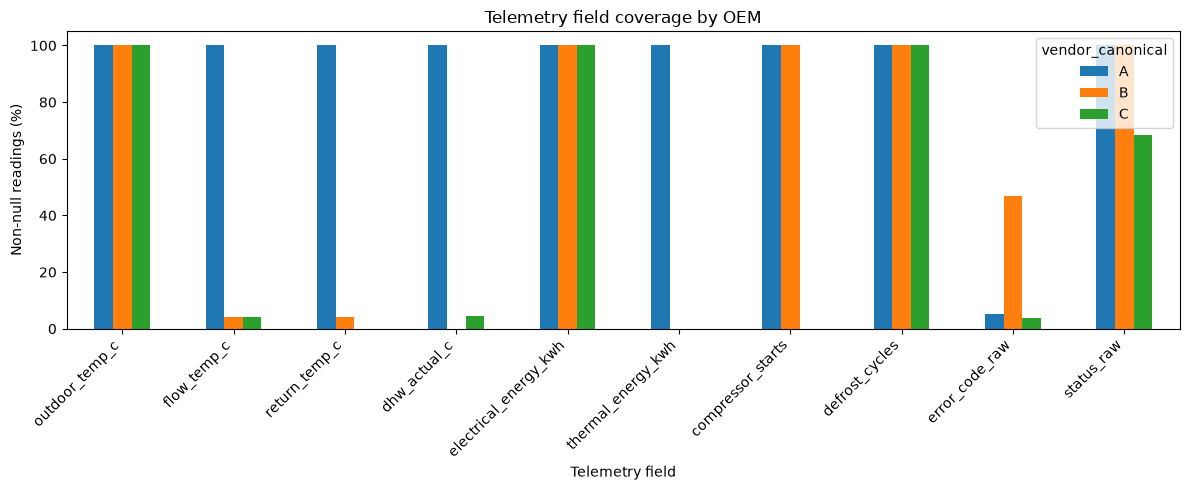

In [165]:
ax = field_coverage.plot(
    kind="bar",
    figsize=(12, 5)
)

ax.set_ylabel("Non-null readings (%)")
ax.set_xlabel("Telemetry field")
ax.set_title("Telemetry field coverage by OEM")

plt.xticks(
    rotation=45,
    ha="right"
)

plt.tight_layout()
plt.show()

### 9.2 Distinguish unsupported fields from intermittent missing data

Aggregate field coverage can hide two different situations:

1. a field is unavailable for entire units or OEM integrations
2. a field is supported but intermittently missing

We therefore calculate field availability at unit level.

In [168]:
unit_field_coverage = (
    telemetry[
        telemetry["unit_id"].notna()
    ]
    .groupby([
        "vendor_canonical",
        "unit_id"
    ])[telemetry_fields]
    .agg(
        lambda x: round(
            x.notna().mean() * 100,
            1
        )
    )
)

for vendor in ["A", "B", "C"]:
    print(f"OEM {vendor}")
    display(
        unit_field_coverage
        .loc[vendor]
        .head()
    )

OEM A


,outdoor_temp_c,flow_temp_c,return_temp_c,dhw_actual_c,electrical_energy_kwh,thermal_energy_kwh,compressor_starts,defrost_cycles,error_code_raw,status_raw
unit_id,,,,,,,,,,
TH-02001,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,3.4,100.0
TH-02002,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,6.8,100.0
TH-02004,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,3.3,100.0
TH-02005,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,0.0,100.0
TH-02006,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,31.7,100.0


OEM B


,outdoor_temp_c,flow_temp_c,return_temp_c,dhw_actual_c,electrical_energy_kwh,thermal_energy_kwh,compressor_starts,defrost_cycles,error_code_raw,status_raw
unit_id,,,,,,,,,,
TH-02141,100.0,3.4,3.4,0.0,100.0,0.0,100.0,100.0,51.7,100.0
TH-02143,100.0,1.8,1.8,0.0,100.0,0.0,100.0,100.0,43.9,100.0
TH-02144,100.0,3.4,3.4,0.0,100.0,0.0,100.0,100.0,46.6,100.0
TH-02145,100.0,12.1,12.1,0.0,100.0,0.0,100.0,100.0,43.1,100.0
TH-02146,100.0,6.7,6.7,0.0,100.0,0.0,100.0,100.0,53.3,100.0


OEM C


,outdoor_temp_c,flow_temp_c,return_temp_c,dhw_actual_c,electrical_energy_kwh,thermal_energy_kwh,compressor_starts,defrost_cycles,error_code_raw,status_raw
unit_id,,,,,,,,,,
TH-02292,100.0,7.7,0.0,1.9,100.0,0.0,0.0,100.0,1.9,71.2
TH-02294,100.0,3.8,0.0,5.7,100.0,0.0,0.0,100.0,5.7,64.2
TH-02296,100.0,1.9,0.0,1.9,100.0,0.0,0.0,100.0,1.9,72.2
TH-02297,100.0,3.8,0.0,1.9,100.0,0.0,0.0,100.0,0.0,58.5
TH-02298,100.0,1.9,0.0,1.9,100.0,0.0,0.0,100.0,27.8,59.3


In [167]:
field_support_by_vendor = {}

for vendor in ["A", "B", "C"]:
    vendor_data = unit_field_coverage.loc[vendor]

    field_support_by_vendor[vendor] = pd.DataFrame({
        "units_with_any_data": (
            vendor_data > 0
        ).sum(),
        "units_with_full_data": (
            vendor_data == 100
        ).sum(),
        "median_unit_coverage_pct": (
            vendor_data.median()
        ).round(1)
    })

for vendor, summary in field_support_by_vendor.items():
    print(f"OEM {vendor}")
    display(summary)

OEM A


,units_with_any_data,units_with_full_data,median_unit_coverage_pct
outdoor_temp_c,97,97,100.0
flow_temp_c,97,97,100.0
return_temp_c,97,97,100.0
dhw_actual_c,97,97,100.0
electrical_energy_kwh,97,97,100.0
thermal_energy_kwh,97,97,100.0
compressor_starts,97,97,100.0
defrost_cycles,97,97,100.0
error_code_raw,86,0,3.4
status_raw,97,97,100.0


OEM B


,units_with_any_data,units_with_full_data,median_unit_coverage_pct
outdoor_temp_c,98,98,100.0
flow_temp_c,86,0,5.0
return_temp_c,86,0,5.0
dhw_actual_c,0,0,0.0
electrical_energy_kwh,98,98,100.0
thermal_energy_kwh,0,0,0.0
compressor_starts,98,98,100.0
defrost_cycles,98,98,100.0
error_code_raw,98,0,46.7
status_raw,98,98,100.0


OEM C


,units_with_any_data,units_with_full_data,median_unit_coverage_pct
outdoor_temp_c,78,78,100.0
flow_temp_c,65,0,3.8
return_temp_c,0,0,0.0
dhw_actual_c,64,0,3.8
electrical_energy_kwh,78,78,100.0
thermal_energy_kwh,0,0,0.0
compressor_starts,0,0,0.0
defrost_cycles,78,78,100.0
error_code_raw,53,0,1.9
status_raw,78,5,66.4


### 9.3 Telemetry coverage conclusions

The telemetry schema is not uniform across OEMs.

#### Cross-OEM fields

The following fields are consistently available across all three OEMs:

- `outdoor_temp_c`
- `electrical_energy_kwh`
- `defrost_cycles`

These are the strongest candidates for a common cross-OEM cockpit layer from a coverage perspective.

However, coverage alone does not guarantee comparable semantics. In particular, the case states that `electrical_energy_kwh` is defined differently by each manufacturer, so it should not yet be used for direct cross-OEM efficiency comparisons.

#### OEM A

OEM A has the richest and most complete telemetry.

For its reporting units, the main operational measurements are effectively complete:

- flow temperature
- return temperature
- DHW temperature
- electrical energy
- thermal energy
- compressor starts
- defrost cycles
- operating status

This means OEM A can support substantially deeper remote diagnosis than the other OEMs.

`error_code_raw` is sparse, which is expected for a field that may only be populated when a fault/status event occurs.

#### OEM B

OEM B exposes a narrower but still useful dataset.

Consistently available fields include:

- outdoor temperature
- electrical energy
- compressor starts
- defrost cycles
- operating status

Flow and return temperatures are present for many units but only on a small fraction of their daily records.

OEM B does not provide:

- DHW temperature
- thermal energy

This prevents several diagnostic questions from being answered directly for OEM B.

#### OEM C

OEM C has the most limited telemetry.

Consistently available fields include:

- outdoor temperature
- electrical energy
- defrost cycles

Flow temperature and DHW temperature appear only sporadically.

The dataset contains no:

- return temperature
- thermal energy
- compressor starts

`status_raw` is also incomplete.

This significantly limits the diagnostic depth that can be supported for OEM C.

### Product implication

The cockpit should not present the same diagnostic capabilities for every OEM.

A better model is:

**common unit view**
+
**OEM-specific diagnostic capabilities**

The product should explicitly communicate when a measurement is unavailable rather than showing an empty value without context.

**🧪 Hypothesis requiring validation:** technicians will trust the cockpit more if OEM-specific data limitations are made explicit instead of attempting to normalize all manufacturers into an artificially uniform view.

## 10. Explore telemetry value distributions by OEM

Field availability tells us what data exists, but not whether the values are comparable or useful.

We next inspect numeric distributions separately for each OEM.

The goals are to identify:

- implausible values
- OEM-specific ranges
- highly skewed fields
- candidate signals for deeper time-series analysis

At this stage, we do not classify values as faults.

A value can be statistically unusual without being operationally abnormal.

In [169]:
numeric_fields = [
    "outdoor_temp_c",
    "flow_temp_c",
    "return_temp_c",
    "dhw_actual_c",
    "electrical_energy_kwh",
    "thermal_energy_kwh",
    "compressor_starts",
    "defrost_cycles"
]

for field in numeric_fields:
    print(f"\n### {field}")

    summary = (
        telemetry[
            telemetry["unit_id"].notna()
        ]
        .groupby("vendor_canonical")[field]
        .describe(
            percentiles=[
                0.01,
                0.05,
                0.25,
                0.50,
                0.75,
                0.95,
                0.99
            ]
        )
        .round(2)
    )

    display(summary)


### outdoor_temp_c


,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
vendor_canonical,,,,,,,,,,,,
A,5689.0,18.41,2.98,10.7,10.7,11.70,17.6,19.2,20.6,21.80,22.3,22.3
B,5769.0,18.40,2.99,10.7,10.7,11.34,17.6,19.1,20.5,22.04,22.3,22.3
C,3999.0,18.74,2.63,11.1,11.1,11.90,17.6,19.2,20.6,22.20,22.3,22.3



### flow_temp_c


,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
vendor_canonical,,,,,,,,,,,,
A,5689.0,15.54,130.81,-999.0,-999.0,30.6,31.4,32.2,33.10,35.20,36.20,37.1
B,243.0,24.03,93.40,-999.0,30.5,30.7,31.5,32.4,33.20,35.09,36.36,36.7
C,163.0,13.23,139.04,-999.0,-999.0,30.7,31.2,32.1,32.95,33.88,35.48,36.2



### return_temp_c


...

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
vendor_canonical,,,,,,,,,,,,
A,5689.0,6.67,3.74,3.0,3.09,3.3,4.4,5.7,7.0,16.3,19.3,22.1
B,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
C,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN



### compressor_starts


,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
vendor_canonical,,,,,,,,,,,,
A,5689.0,8.50,2.96,2.0,2.0,4.0,6.0,9.0,10.0,13.0,16.0,19.0
B,5769.0,8.95,4.27,2.0,2.0,4.0,7.0,9.0,11.0,14.0,30.0,46.0
C,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN



### defrost_cycles


,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
vendor_canonical,,,,,,,,,,,,
A,5689.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
B,5769.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
C,3999.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


### 10.1 Visualize numeric distributions

We visualize each metric separately by OEM.

The purpose is exploratory:

- detect extreme values
- identify whether OEM distributions differ materially
- decide which signals need OEM-specific interpretation

No threshold derived from these distributions is treated as a service threshold yet.

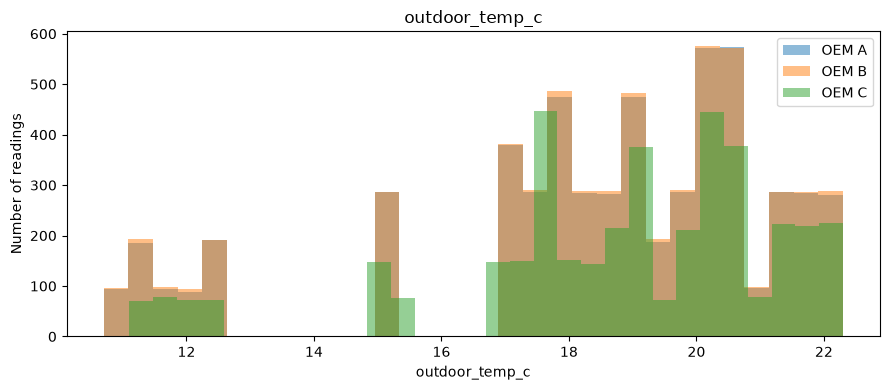

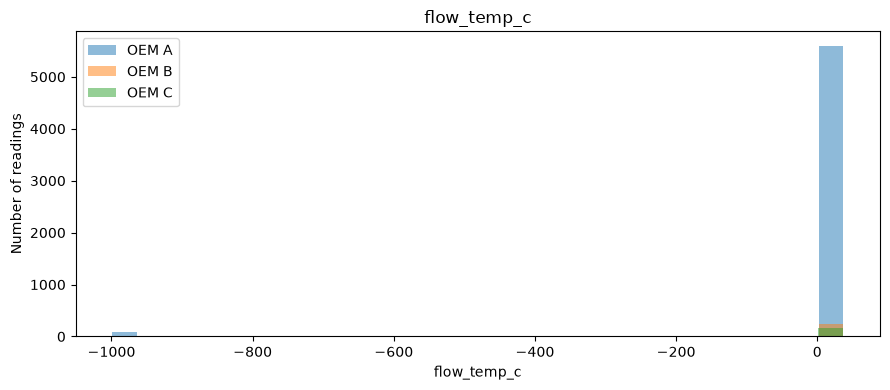

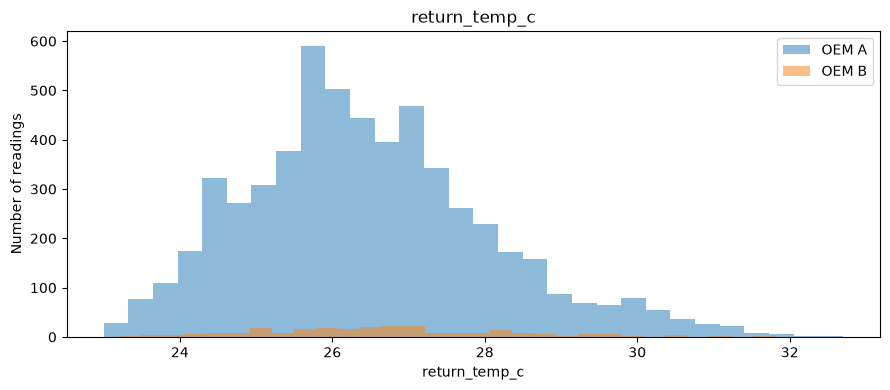

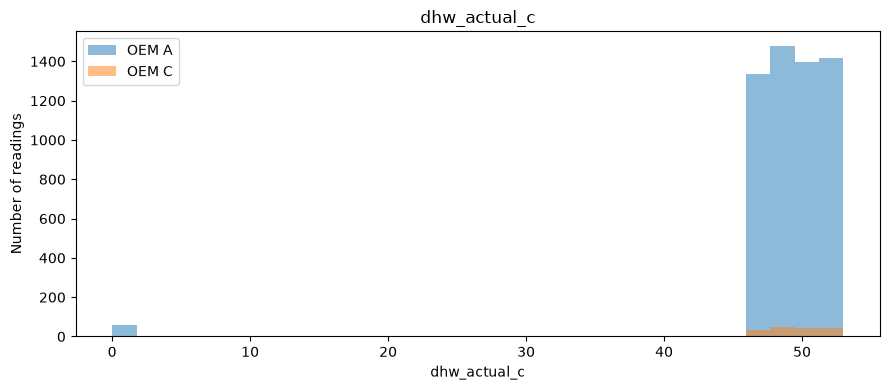

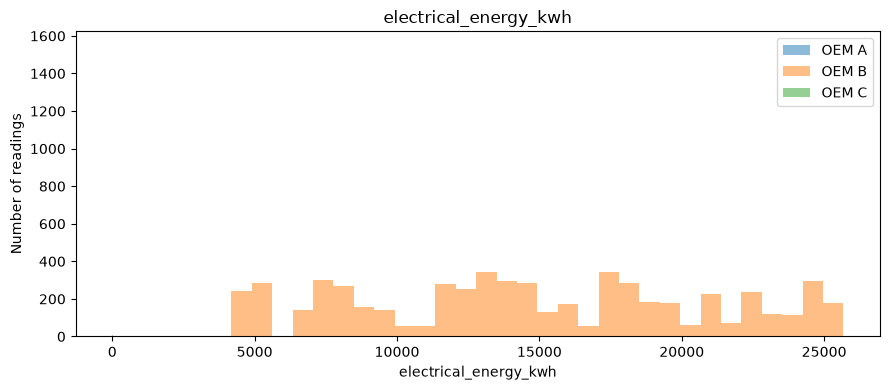

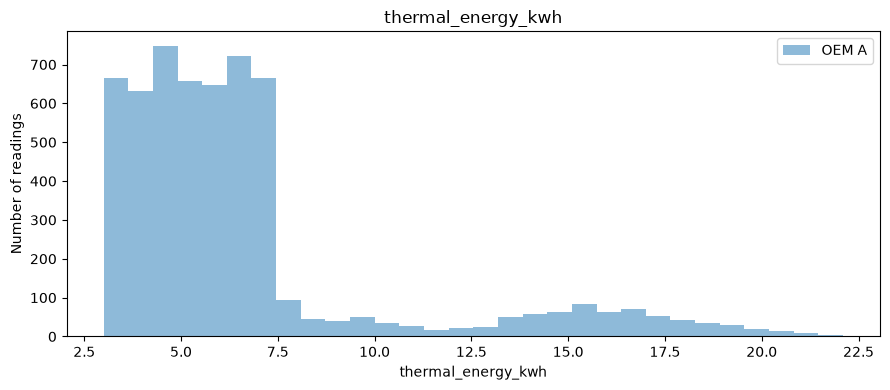

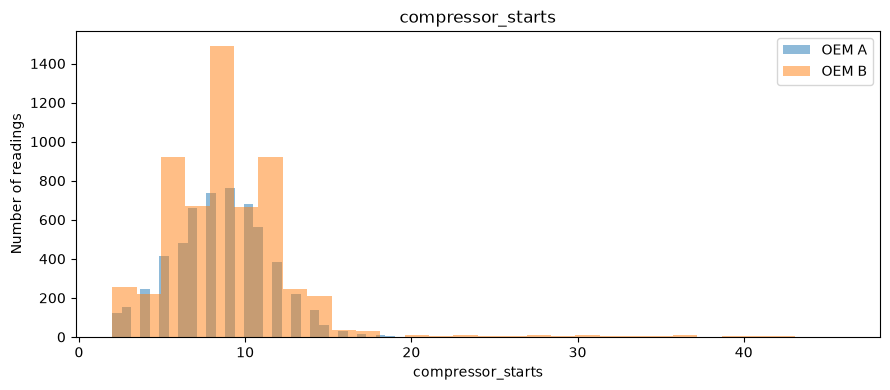

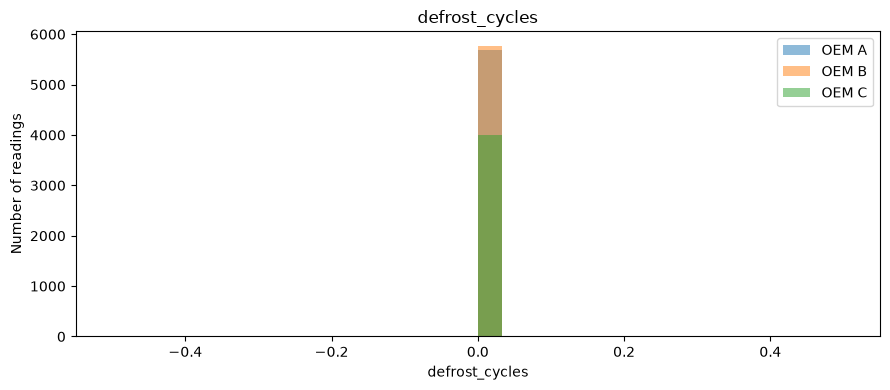

In [170]:
for field in numeric_fields:

    fig, ax = plt.subplots(
        figsize=(9, 4)
    )

    for vendor, group in (
        telemetry[
            telemetry["unit_id"].notna()
        ]
        .groupby("vendor_canonical")
    ):

        values = group[field].dropna()

        if len(values) == 0:
            continue

        ax.hist(
            values,
            bins=30,
            alpha=0.5,
            label=f"OEM {vendor}"
        )

    ax.set_title(field)
    ax.set_xlabel(field)
    ax.set_ylabel("Number of readings")
    ax.legend()

    plt.tight_layout()
    plt.show()

### 10.2 Treat energy fields conservatively

The dataset contains both electrical and thermal energy measurements, but they cannot currently support a reliable cross-OEM efficiency comparison.

The case explicitly states that manufacturers do not define `electrical_energy_kwh` consistently and that no further documentation is available.

Therefore:

- we do not calculate a cross-OEM COP or efficiency score
- we do not rank units or OEMs by electrical consumption
- OEM A may allow exploratory thermal/electrical relationships because both fields are available, but their semantics would still require validation

**🟡 Assumption:** numeric values with documented units can be explored statistically, but a derived operational metric should only be used when the semantics of all input fields are understood.

## 11. Explore raw operating statuses and error signals

The raw status and error fields are vendor-specific and undocumented.

We therefore do not attempt to translate them into fault descriptions.

Instead, we analyze:

- which values occur
- how frequently they occur
- how many units they affect
- whether signals persist across multiple days
- whether some signals are so common that they are unlikely to be useful as front-page alerts

This can help distinguish potentially actionable signals from normal vendor-system noise.

In [171]:
for vendor in ["A", "B", "C"]:

    vendor_data = telemetry[
        (telemetry["vendor_canonical"] == vendor)
        & telemetry["unit_id"].notna()
    ]

    print(f"\nOEM {vendor} — status_raw")

    display(
        vendor_data["status_raw"]
        .value_counts(dropna=False)
        .head(20)
        .to_frame("readings")
    )

    print(f"OEM {vendor} — error_code_raw")

    display(
        vendor_data["error_code_raw"]
        .value_counts(dropna=False)
        .head(20)
        .to_frame("readings")
    )


OEM A — status_raw


,readings
status_raw,
OK,2813
ok,2787
warn,89


OEM A — error_code_raw


,readings
error_code_raw,
NaN,5392
E-211,143
E-317,56
E-104,51
E-505,47



OEM B — status_raw


...

,readings
error_code_raw,
NaN,3072
6021,2475
3104,116
7702,61
1188,45



OEM C — status_raw


,readings
status_raw,
OK,1453
warn,1277
NaN,1269


OEM C — error_code_raw


,readings
error_code_raw,
NaN,3846
ALM_HP_LOWFLOW,56
ALM_SM_LINK,53
ALM_HP_HP_SWITCH,44


### 11.1 Measure recurrence of raw error signals

A raw code appearing once is operationally different from the same code appearing repeatedly on the same unit.

We therefore measure recurrence at unit level without assigning a diagnostic meaning to the code.

In [173]:
unit_error_recurrence = (
    telemetry[
        telemetry["error_code_raw"].notna()
        & telemetry["unit_id"].notna()
    ]
    .groupby(
        [
            "vendor_canonical",
            "unit_id",
            "error_code_raw"
        ]
    )
    .agg(
        days_with_code=("reading_date", "nunique"),
        first_seen=("reading_date", "min"),
        last_seen=("reading_date", "max")
    )
    .reset_index()
    .sort_values(
        "days_with_code",
        ascending=False
    )
)

display(
    unit_error_recurrence.head(30)
)

,vendor_canonical,unit_id,error_code_raw,days_with_code,first_seen,last_seen
373,B,TH-02279,6021,36,2026-06-01,2026-07-28
294,B,TH-02231,6021,35,2026-06-01,2026-07-30
344,B,TH-02262,6021,33,2026-06-01,2026-07-30
359,B,TH-02270,6021,33,2026-06-03,2026-07-30
321,B,TH-02248,6021,32,2026-06-01,2026-07-30
281,B,TH-02223,6021,32,2026-06-01,2026-07-30
196,B,TH-02162,6021,32,2026-06-02,2026-07-28
363,B,TH-02272,6021,32,2026-06-05,2026-07-29
351,B,TH-02267,6021,32,2026-06-01,2026-07-29
336,B,TH-02258,6021,31,2026-06-03,2026-07-30


### 11.2 Measure prevalence of raw error signals

A frequently occurring code is not automatically a severe fault.

If a code appears across many units or on a large share of otherwise normal reporting days, it may represent a common state rather than an actionable service event.

We therefore measure both total occurrences and the number of affected units.

In [174]:
error_code_summary = (
    telemetry[
        telemetry["error_code_raw"].notna()
        & telemetry["unit_id"].notna()
    ]
    .groupby(
        [
            "vendor_canonical",
            "error_code_raw"
        ]
    )
    .agg(
        readings=("reading_date", "size"),
        affected_units=("unit_id", "nunique"),
        first_seen=("reading_date", "min"),
        last_seen=("reading_date", "max")
    )
    .reset_index()
    .sort_values(
        [
            "vendor_canonical",
            "readings"
        ],
        ascending=[
            True,
            False
        ]
    )
)

display(error_code_summary)

,vendor_canonical,error_code_raw,readings,affected_units,first_seen,last_seen
1,A,E-211,143,46,2026-06-01,2026-07-30
2,A,E-317,56,46,2026-06-01,2026-07-29
0,A,E-104,51,38,2026-06-02,2026-07-27
3,A,E-505,47,33,2026-06-01,2026-07-30
6,B,6021,2475,98,2026-06-01,2026-07-30
5,B,3104,116,47,2026-06-01,2026-07-30
7,B,7702,61,50,2026-06-02,2026-07-30
4,B,1188,45,39,2026-06-02,2026-07-28
9,C,ALM_HP_LOWFLOW,56,4,2026-07-17,2026-07-30
10,C,ALM_SM_LINK,53,39,2026-06-01,2026-07-30


### 10.3 Numeric telemetry conclusions

The distribution analysis reveals several important data-quality and product constraints.

#### Flow temperature

Most valid flow-temperature readings cluster around approximately 30–36 °C.

However, the dataset also contains `-999` values for OEM A, B, and C.

`-999 °C` is not a plausible physical flow temperature and is therefore likely to represent a source-system sentinel or missing-value encoding rather than a real measurement.

**🧪 Hypothesis requiring validation:** `-999` represents unavailable or invalid temperature data.

Until its meaning is confirmed, it should be treated as invalid for analytical calculations and displayed as unavailable rather than as a temperature.

#### Return temperature

Return-temperature readings are available for OEM A and sparsely for OEM B.

OEM C contains no return-temperature readings.

Where present, values are concentrated around approximately 23–32 °C.

This means flow/return relationships can support analysis for OEM A and limited analysis for OEM B, but not OEM C.

#### Domestic hot water temperature

OEM A and OEM C contain DHW measurements, while OEM B contains none.

Most observed values are around 46–53 °C, but some readings are exactly `0`.

A daily mean DHW temperature of `0 °C` is unusual enough to require investigation before it is interpreted as a real operating condition.

**🧪 Hypothesis requiring validation:** zero-valued DHW readings may represent missing or invalid measurements rather than actual water temperature.

#### Electrical energy

OEM A and C report values predominantly in the low single digits, while OEM B reports values in the thousands to tens of thousands.

This confirms the warning in the case brief that `electrical_energy_kwh` does not have consistent semantics across manufacturers.

The field must therefore not be compared directly across OEMs.

Negative readings are also present for OEM A and C and require validation before use.

#### Thermal energy

Thermal energy is available only for OEM A.

It therefore cannot support a cross-OEM efficiency metric.

#### Compressor starts

OEM A and B both expose compressor-start counts.

Their typical distributions are similar, but OEM B contains a much longer upper tail, reaching as high as 46 starts per day compared with 19 for OEM A.

This may provide an OEM-specific candidate signal for deeper investigation, but no service threshold can yet be inferred from the distribution alone.

#### Defrost cycles

All observed `defrost_cycles` values are zero across all OEMs during the June–July dataset.

The field therefore contains no discriminating information for service prioritization in this extract.

### Product implication

The raw telemetry should not be transformed into one universal cross-OEM health score.

The first version should instead combine:

- cross-OEM signals whose semantics are understood
- OEM-specific signals where coverage supports them
- explicit unavailable / invalid-data states

Statistical outliers alone are not treated as faults.

### 10.4 Inspect suspicious numeric values before cleaning

Several values appear to represent source-system defects or special encodings.

Before excluding them from analysis, we quantify:

- `-999` temperature readings
- zero-valued DHW readings
- negative electrical-energy readings

The raw columns remain unchanged. Any later cleaned values will be stored separately.

In [175]:
suspicious_values = []

for vendor in ["A", "B", "C"]:
    vendor_data = telemetry[
        telemetry["vendor_canonical"] == vendor
    ]

    suspicious_values.append({
        "vendor": vendor,
        "flow_minus_999": (
            vendor_data["flow_temp_c"] == -999
        ).sum(),
        "return_minus_999": (
            vendor_data["return_temp_c"] == -999
        ).sum(),
        "dhw_zero": (
            vendor_data["dhw_actual_c"] == 0
        ).sum(),
        "negative_electrical_energy": (
            vendor_data["electrical_energy_kwh"] < 0
        ).sum()
    })

suspicious_value_summary = pd.DataFrame(
    suspicious_values
)

display(suspicious_value_summary)

,vendor,flow_minus_999,return_minus_999,dhw_zero,negative_electrical_energy
0,A,93,0,59,25
1,B,2,0,0,0
2,C,3,0,3,17


### 10.5 Identify which units contain suspicious measurements

A suspicious value that occurs repeatedly on the same unit may indicate a different problem from a single isolated reading.

We therefore inspect both occurrence count and affected-unit count.

In [176]:
suspicious_unit_summary = []

checks = {
    "flow_temp_-999": telemetry["flow_temp_c"] == -999,
    "return_temp_-999": telemetry["return_temp_c"] == -999,
    "dhw_actual_0": telemetry["dhw_actual_c"] == 0,
    "negative_electrical_energy": (
        telemetry["electrical_energy_kwh"] < 0
    )
}

for signal, mask in checks.items():

    subset = telemetry[
        mask
        & telemetry["unit_id"].notna()
    ]

    suspicious_unit_summary.append({
        "signal": signal,
        "readings": len(subset),
        "affected_units": subset["unit_id"].nunique()
    })

display(
    pd.DataFrame(suspicious_unit_summary)
)

,signal,readings,affected_units
0,flow_temp_-999,98,66
1,return_temp_-999,0,0
2,dhw_actual_0,62,44
3,negative_electrical_energy,42,38


## 11. Raw status and error-signal conclusions

The raw status and error fields should not be interpreted as standardized faults.

Their behavior differs substantially by OEM.

### OEM A

`status_raw` is dominated by `OK` and `ok`, with a much smaller number of `warn` readings.

The difference between `OK` and `ok` appears textual rather than semantic.

**🟡 Assumption:** `OK` and `ok` represent the same OEM A status and can be normalized for analysis.

OEM A exposes four error-code values:

- `E-211`
- `E-317`
- `E-104`
- `E-505`

None dominates the entire reporting population.

Their technical meaning is unknown, so they can be ranked by prevalence and recurrence but not translated into diagnoses.

### OEM B

OEM B's status field is dominated by status `0`, with a smaller number of status `2` readings.

The raw error code `6021` appears 2,475 times and affects all 98 reporting OEM B units.

Many individual units show code `6021` on roughly half of their reporting days.

This makes `6021` poorly suited to a front-page service alert unless vendor documentation establishes that it represents an actionable condition.

**🧪 Hypothesis requiring validation:** OEM B code `6021` represents a common operating or informational state rather than an exceptional service fault.

Codes `3104`, `7702`, and `1188` are substantially less frequent and may have greater discriminatory value, but their meaning remains unknown.

### OEM C

OEM C exposes human-readable alarm-like strings:

- `ALM_HP_LOWFLOW`
- `ALM_SM_LINK`
- `ALM_HP_HP_SWITCH`

Although their names appear suggestive, no vendor code documentation is provided.

We therefore preserve the raw strings and do not infer a technical diagnosis from their names alone.

`ALM_HP_LOWFLOW` is notable because it occurs 56 times but affects only four units. This concentration makes it a stronger candidate for unit-level investigation than signals distributed broadly across the installed base.

### Product implication

Raw error-code presence is not sufficient to determine urgency.

A useful cockpit signal should account for:

- OEM
- prevalence across the fleet
- recurrence on the same unit
- recency
- correlation with other observable telemetry

Common signals such as OEM B `6021` should be kept off the primary attention list unless their meaning is validated.

### 11.3 Normalize status labels for analysis only

Some raw status values differ only in textual formatting.

We preserve `status_raw` and create a separate normalized field for frequency analysis.

In [177]:
telemetry["status_normalized"] = (
    telemetry["status_raw"]
    .astype("string")
    .str.strip()
    .str.upper()
)

for vendor in ["A", "B", "C"]:

    print(f"OEM {vendor}")

    display(
        telemetry[
            telemetry["vendor_canonical"] == vendor
        ]["status_normalized"]
        .value_counts(
            dropna=False
        )
        .to_frame("readings")
    )

OEM A


,readings
status_normalized,
OK,5600
WARN,89


OEM B


,readings
status_normalized,
0,5547
2,222


OEM C


,readings
status_normalized,
OK,1453
WARN,1277
<NA>,1269


### 11.4 Measure how concentrated each error signal is

A signal occurring frequently across nearly every unit is less useful for prioritization than a signal concentrated on a small number of units.

We therefore calculate the share of each OEM's reporting units affected by each raw error code.

In [178]:
reporting_unit_count_by_vendor = (
    telemetry[
        telemetry["unit_id"].notna()
    ]
    .groupby("vendor_canonical")["unit_id"]
    .nunique()
)

error_code_summary["reporting_units"] = (
    error_code_summary["vendor_canonical"]
    .map(reporting_unit_count_by_vendor)
)

error_code_summary["affected_unit_pct"] = (
    error_code_summary["affected_units"]
    / error_code_summary["reporting_units"]
    * 100
).round(1)

display(
    error_code_summary[
        [
            "vendor_canonical",
            "error_code_raw",
            "readings",
            "affected_units",
            "affected_unit_pct",
            "first_seen",
            "last_seen"
        ]
    ]
)

,vendor_canonical,error_code_raw,readings,affected_units,affected_unit_pct,first_seen,last_seen
1,A,E-211,143,46,47.4,2026-06-01,2026-07-30
2,A,E-317,56,46,47.4,2026-06-01,2026-07-29
0,A,E-104,51,38,39.2,2026-06-02,2026-07-27
3,A,E-505,47,33,34.0,2026-06-01,2026-07-30
6,B,6021,2475,98,100.0,2026-06-01,2026-07-30
5,B,3104,116,47,48.0,2026-06-01,2026-07-30
7,B,7702,61,50,51.0,2026-06-02,2026-07-30
4,B,1188,45,39,39.8,2026-06-02,2026-07-28
9,C,ALM_HP_LOWFLOW,56,4,5.1,2026-07-17,2026-07-30
10,C,ALM_SM_LINK,53,39,50.0,2026-06-01,2026-07-30


## 12. Candidate signals for the "Needs attention" worklist

The EDA now supports a small number of signals that can be derived without pretending to understand undocumented OEM semantics.

The first version should separate **observed conditions** from **diagnoses**.

### Signal 1 — Telemetry stopped

A unit previously reported data but its most recent reading is materially older than the end of the dataset.

Evidence:

- three connected units stop reporting on 20 July
- all three are ten days stale at the end of the extract
- the units span OEM A, B, and C

This is a high-confidence data-health observation but not evidence of equipment failure.

### Signal 2 — Recurrent uncommon raw error signal

A vendor-specific raw error signal occurs repeatedly on the same unit and is not ubiquitous across that OEM's installed base.

This can prioritize investigation without translating the error code into a diagnosis.

Signals that occur across most units, such as OEM B `6021`, should be deprioritized unless vendor documentation proves otherwise.

### Signal 3 — Persistent abnormal measurement

A measurement remains materially different from the same unit's historical pattern or its OEM peer distribution.

This requires additional validation before becoming a production rule because several fields contain invalid or ambiguous source values.

### Signal 4 — Data-quality limitation

The cockpit should explicitly surface when a requested diagnostic field is:

- unavailable for the OEM
- missing for the current observation
- stale
- invalid or encoded with a suspected sentinel value

This is not a heat-pump fault, but it directly affects whether a technician can trust the available evidence.

### Excluded from the first attention logic

The following are not yet defensible attention signals:

- cross-OEM electrical-energy comparison
- COP / efficiency scoring
- defrost-cycle anomalies in this dataset
- absolute diagnosis from undocumented raw fault codes
- one universal temperature threshold across all OEMs

### 12.1 Create the first high-confidence attention signal: stale telemetry

For the first candidate worklist, we flag reporting units whose latest reading is at least two days older than the final date in the supplied extract.

The threshold is exploratory rather than a validated operational SLA.

**🟡 Assumption:** two or more days without telemetry is sufficiently unusual in this dataset to justify service-team review.

In [179]:
reporting_units["signal_stale_telemetry"] = (
    reporting_units["days_from_last_to_end"] >= 2
)

display(
    reporting_units[
        reporting_units["signal_stale_telemetry"]
    ][
        [
            "unit_id",
            "vendor_canonical",
            "connectivity",
            "latest_reading",
            "days_from_last_to_end",
            "continuity_pct"
        ]
    ]
)

,unit_id,vendor_canonical,connectivity,latest_reading,days_from_last_to_end,continuity_pct
22,TH-02023,A,connected,2026-07-20,10,94.0
279,TH-02280,B,connected,2026-07-20,10,98.0
303,TH-02304,C,connected,2026-07-20,10,88.0


### 12.2 Identify recurrent error signals without diagnosing them

We next rank unit-level raw codes by recurrence while excluding codes that are highly prevalent across their OEM population.

This is exploratory prioritization logic, not a fault classifier.

In [180]:
error_context = unit_error_recurrence.merge(
    error_code_summary[
        [
            "vendor_canonical",
            "error_code_raw",
            "affected_unit_pct"
        ]
    ],
    on=[
        "vendor_canonical",
        "error_code_raw"
    ],
    how="left"
)

recurrent_uncommon_errors = (
    error_context[
        (error_context["days_with_code"] >= 2)
        & (error_context["affected_unit_pct"] < 80)
    ]
    .sort_values(
        [
            "days_with_code",
            "affected_unit_pct"
        ],
        ascending=[
            False,
            True
        ]
    )
)

display(
    recurrent_uncommon_errors.head(30)
)

,vendor_canonical,unit_id,error_code_raw,days_with_code,first_seen,last_seen,affected_unit_pct
95,A,TH-02073,E-211,18,2026-07-04,2026-07-29,47.4
98,A,TH-02006,E-211,17,2026-06-27,2026-07-29,47.4
99,A,TH-02038,E-211,16,2026-07-04,2026-07-30,47.4
101,A,TH-02091,E-211,16,2026-07-04,2026-07-30,47.4
102,B,TH-02290,3104,15,2026-06-10,2026-07-30,48.0
103,C,TH-02298,ALM_HP_LOWFLOW,14,2026-07-17,2026-07-30,5.1
104,C,TH-02395,ALM_HP_LOWFLOW,14,2026-07-17,2026-07-30,5.1
105,C,TH-02398,ALM_HP_LOWFLOW,14,2026-07-17,2026-07-30,5.1
106,C,TH-02312,ALM_HP_LOWFLOW,14,2026-07-17,2026-07-30,5.1
107,A,TH-02132,E-211,14,2026-07-07,2026-07-30,47.4


### 12.3 Next analytical step

The remaining task is to combine the strongest defensible signals into a short technician-review list.

Before doing so, we should inspect the recent time series of the highest-ranked candidate units and determine whether multiple independent signals occur on the same installation.

The final worklist should prefer units where several pieces of evidence agree rather than ranking units from one unexplained metric alone.

### 12.4 Conclusions from status and error-code prevalence

The status and error analysis shows that several raw signals are too common to use directly as service alerts.

#### OEM A

After normalizing textual case:

- `OK` appears 5,600 times
- `WARN` appears 89 times

`WARN` is therefore relatively uncommon and may be useful as a supporting attention signal.

The most common error code, `E-211`, affects 47.4% of reporting OEM A units. Other A error codes affect between roughly one third and one half of the connected fleet.

Because these codes are widely distributed and their meanings are undocumented, code presence alone is not sufficient evidence that a unit requires intervention.

#### OEM B

Status `0` dominates the dataset, while status `2` occurs much less frequently.

Error code `6021` affects 100% of reporting OEM B units and occurs on many units repeatedly.

This makes `6021` unsuitable as a front-page attention signal without additional vendor documentation.

The remaining B codes also affect approximately 40–51% of reporting units, meaning prevalence alone does not provide strong discrimination.

#### OEM C

OEM C contains a high proportion of `WARN` readings:

- `OK`: 1,453 readings
- `WARN`: 1,277 readings
- missing status: 1,269 readings

`WARN` is therefore too common to treat as an alert by itself.

The strongest discriminating raw signal is `ALM_HP_LOWFLOW`:

- 56 readings
- only 4 affected units
- all four affected units show the code repeatedly
- the signal appears from 17 July through the end of the dataset

This makes it a strong candidate for investigation, although its technical meaning remains undocumented.

### Product implication

Raw status values should not be converted directly into a universal red/amber/green health state.

Useful prioritization requires context:

- how rare the signal is within the OEM population
- how often it repeats on the same unit
- whether it is recent
- whether independent telemetry signals support it

A common status or code may still be operationally important, but the available data does not justify treating prevalence as severity.

### 12.5 Refine the error-signal candidate logic

The previous exploratory filter considered any recurring code affecting fewer than 80% of an OEM fleet.

The results show that this is still too broad: several codes affecting 40–50% of an OEM population pass the filter despite offering little prioritization value.

We therefore make the candidate logic more selective.

For exploration, a raw error signal is considered **discriminating** when:

- it occurs on at least two days for the same unit
- it affects fewer than 20% of reporting units for that OEM
- it has occurred recently relative to the end of the dataset

These thresholds are analytical heuristics, not validated service rules.

**🟡 Assumption:** signals affecting fewer than 20% of an OEM's reporting units are more useful for prioritization than fleet-wide or very common signals.

**🟡 Assumption:** a signal seen within the final seven days of the extract is more relevant for a "tomorrow morning" worklist than an equally recurrent signal last seen several weeks earlier.

In [181]:
error_context["days_since_last_error"] = (
    dataset_end - error_context["last_seen"]
).dt.days

discriminating_errors = (
    error_context[
        (error_context["days_with_code"] >= 2)
        & (error_context["affected_unit_pct"] < 20)
        & (error_context["days_since_last_error"] <= 7)
    ]
    .sort_values(
        [
            "days_with_code",
            "days_since_last_error"
        ],
        ascending=[
            False,
            True
        ]
    )
)

display(
    discriminating_errors[
        [
            "vendor_canonical",
            "unit_id",
            "error_code_raw",
            "days_with_code",
            "affected_unit_pct",
            "first_seen",
            "last_seen",
            "days_since_last_error"
        ]
    ]
)

,vendor_canonical,unit_id,error_code_raw,days_with_code,affected_unit_pct,first_seen,last_seen,days_since_last_error
103,C,TH-02298,ALM_HP_LOWFLOW,14,5.1,2026-07-17,2026-07-30,0
104,C,TH-02395,ALM_HP_LOWFLOW,14,5.1,2026-07-17,2026-07-30,0
105,C,TH-02398,ALM_HP_LOWFLOW,14,5.1,2026-07-17,2026-07-30,0
106,C,TH-02312,ALM_HP_LOWFLOW,14,5.1,2026-07-17,2026-07-30,0


### 12.6 Inspect recent status warnings at unit level

A raw `WARN` status is only useful if it is sufficiently unusual for the relevant OEM.

OEM C produces `WARN` frequently, so the status alone has limited prioritization value.

OEM A produces relatively few `WARN` readings, making repeated or recent warnings potentially more useful.

We therefore summarize warning recurrence by unit rather than treating every warning reading equally.

In [182]:
warning_summary = (
    telemetry[
        (telemetry["status_normalized"] == "WARN")
        & telemetry["unit_id"].notna()
    ]
    .groupby(
        [
            "vendor_canonical",
            "unit_id"
        ]
    )
    .agg(
        warn_days=("reading_date", "nunique"),
        first_warn=("reading_date", "min"),
        last_warn=("reading_date", "max")
    )
    .reset_index()
)

warning_summary["days_since_last_warn"] = (
    dataset_end - warning_summary["last_warn"]
).dt.days

display(
    warning_summary
    .sort_values(
        [
            "warn_days",
            "days_since_last_warn"
        ],
        ascending=[
            False,
            True
        ]
    )
    .head(30)
)

,vendor_canonical,unit_id,warn_days,first_warn,last_warn,days_since_last_warn
51,C,TH-02299,25,2026-06-01,2026-07-30,0
65,C,TH-02319,24,2026-06-02,2026-07-23,7
106,C,TH-02383,23,2026-06-01,2026-07-30,0
108,C,TH-02385,23,2026-06-01,2026-07-30,0
72,C,TH-02335,23,2026-06-04,2026-07-29,1
115,C,TH-02397,23,2026-06-01,2026-07-29,1
117,C,TH-02399,23,2026-06-02,2026-07-29,1
71,C,TH-02334,22,2026-06-01,2026-07-30,0
59,C,TH-02311,22,2026-06-01,2026-07-28,2
67,C,TH-02323,22,2026-06-01,2026-07-28,2


## 13. Inspect candidate units using multiple independent signals

The service worklist should not prioritize units from one opaque metric alone.

We therefore combine several independently observable signals:

1. telemetry has stopped
2. a relatively rare raw error signal recurs
3. recent warning status is present
4. suspicious or invalid measurements occur

The objective is not to calculate a universal health score.

Instead, each unit can carry multiple simultaneous attention signals, allowing the technician or dispatcher to understand *why* it was surfaced.

In [183]:
candidate_units = (
    reporting_units[
        [
            "unit_id",
            "vendor_canonical",
            "latest_reading",
            "days_from_last_to_end",
            "continuity_pct"
        ]
    ]
    .copy()
)

candidate_units["stale_telemetry"] = (
    candidate_units["days_from_last_to_end"] >= 2
)

In [184]:
rare_error_by_unit = (
    discriminating_errors
    .groupby(
        [
            "vendor_canonical",
            "unit_id"
        ]
    )
    .agg(
        recurring_error_days=("days_with_code", "max"),
        recent_error_code=(
            "error_code_raw",
            lambda x: ", ".join(
                sorted(
                    set(
                        str(v)
                        for v in x
                    )
                )
            )
        ),
        latest_error=("last_seen", "max")
    )
    .reset_index()
)

candidate_units = candidate_units.merge(
    rare_error_by_unit,
    on=[
        "vendor_canonical",
        "unit_id"
    ],
    how="left"
)

In [185]:
recent_warning_by_unit = (
    warning_summary[
        warning_summary["days_since_last_warn"] <= 7
    ][
        [
            "vendor_canonical",
            "unit_id",
            "warn_days",
            "last_warn"
        ]
    ]
)

candidate_units = candidate_units.merge(
    recent_warning_by_unit,
    on=[
        "vendor_canonical",
        "unit_id"
    ],
    how="left"
)

candidate_units["recent_warning"] = (
    candidate_units["warn_days"]
    .fillna(0)
    .gt(0)
)

### 13.1 Count independent attention signals

For exploration, we count how many independently derived conditions apply to each unit.

This count is used only to identify units worth inspecting manually.

It is not a production severity score because the signals have not been calibrated against real service outcomes.

In [186]:
candidate_units["attention_signal_count"] = (
    candidate_units["stale_telemetry"].astype(int)
    + candidate_units["recent_warning"].astype(int)
    + candidate_units["recurring_error_days"].notna().astype(int)
)

candidate_review = (
    candidate_units[
        candidate_units["attention_signal_count"] > 0
    ]
    .sort_values(
        [
            "attention_signal_count",
            "recurring_error_days",
            "days_from_last_to_end"
        ],
        ascending=[
            False,
            False,
            False
        ]
    )
)

display(
    candidate_review[
        [
            "unit_id",
            "vendor_canonical",
            "attention_signal_count",
            "stale_telemetry",
            "recent_warning",
            "warn_days",
            "recent_error_code",
            "recurring_error_days",
            "latest_error",
            "latest_reading",
            "days_from_last_to_end"
        ]
    ]
    .head(30)
)

,unit_id,vendor_canonical,attention_signal_count,stale_telemetry,recent_warning,warn_days,recent_error_code,recurring_error_days,latest_error,latest_reading,days_from_last_to_end
199,TH-02298,C,2,False,True,17.0,ALM_HP_LOWFLOW,14.0,2026-07-30,2026-07-30,0
209,TH-02312,C,2,False,True,17.0,ALM_HP_LOWFLOW,14.0,2026-07-30,2026-07-30,0
262,TH-02395,C,2,False,True,18.0,ALM_HP_LOWFLOW,14.0,2026-07-30,2026-07-30,0
265,TH-02398,C,2,False,True,18.0,ALM_HP_LOWFLOW,14.0,2026-07-30,2026-07-30,0
16,TH-02023,A,1,True,False,NaN,NaN,NaN,NaT,2026-07-20,10
187,TH-02280,B,1,True,False,NaN,NaN,NaN,NaT,2026-07-20,10
204,TH-02304,C,1,True,False,NaN,NaN,NaN,NaT,2026-07-20,10
239,TH-02357,C,1,False,True,18.0,NaN,NaN,NaT,2026-07-29,1
27,TH-02038,A,1,False,True,7.0,NaN,NaN,NaT,2026-07-30,0
60,TH-02086,A,1,False,True,1.0,NaN,NaN,NaT,2026-07-30,0


### 13.2 Current strongest candidates from the EDA

Before inspecting individual time series, two groups stand out:

#### Stale telemetry

Three connected units stopped reporting on 20 July:

- `TH-02023` — OEM A
- `TH-02280` — OEM B
- `TH-02304` — OEM C

All are ten days stale at the end of the dataset.

This is a high-confidence observation, although the synchronized stop date suggests the cause may lie in telemetry/integration rather than in the heat pumps themselves.

#### Recurrent OEM C `ALM_HP_LOWFLOW`

Four OEM C units show this raw code on 14 days each:

- `TH-02298`
- `TH-02395`
- `TH-02398`
- `TH-02312`

The code affects only 5.1% of reporting OEM C units and appears repeatedly from 17 July through 30 July.

This makes the four units strong candidates for manual review.

The raw code name appears meaningful, but without vendor documentation we do not convert it into a technical diagnosis.

**🧪 Hypothesis requiring validation:** the four OEM C units with persistent `ALM_HP_LOWFLOW` represent a meaningful service cohort rather than a benign OEM state.

### 13.3 Refine warning signals by OEM prevalence

The first candidate logic treated every recent `WARN` status as an independent attention signal.

The results show that this is too broad:

- OEM A produces relatively few `WARN` readings
- OEM C produces `WARN` frequently across the fleet

A warning therefore carries different information depending on the OEM.

We should not count a common OEM status as additional evidence simply because its label reads `WARN`.

**🧪 Hypothesis requiring validation:** a status signal is useful for prioritization only when it is relatively uncommon within that OEM population.

In [187]:
warning_prevalence = (
    telemetry[
        telemetry["unit_id"].notna()
    ]
    .groupby("vendor_canonical")
    .agg(
        reporting_units=("unit_id", "nunique"),
        warning_units=(
            "unit_id",
            lambda x: x[
                telemetry.loc[x.index, "status_normalized"] == "WARN"
            ].nunique()
        )
    )
)

warning_prevalence["warning_unit_pct"] = (
    warning_prevalence["warning_units"]
    / warning_prevalence["reporting_units"]
    * 100
).round(1)

display(warning_prevalence)

,reporting_units,warning_units,warning_unit_pct
vendor_canonical,,,
A,97,46,47.4
B,98,0,0.0
C,78,73,93.6


### 13.4 Use warnings only where they discriminate

For exploratory prioritization, we only treat a recent warning as an independent attention signal when `WARN` affects fewer than 20% of reporting units for that OEM.

The threshold is a heuristic for this case study, not a validated service rule.

**🟡 Assumption:** a status affecting fewer than 20% of an OEM's reporting fleet is sufficiently uncommon to add prioritization value.

In [188]:
warning_unit_pct_map = (
    warning_prevalence["warning_unit_pct"]
    .to_dict()
)

candidate_units["warning_unit_pct"] = (
    candidate_units["vendor_canonical"]
    .map(warning_unit_pct_map)
)

candidate_units["discriminating_warning"] = (
    candidate_units["recent_warning"]
    & (candidate_units["warning_unit_pct"] < 20)
)

In [189]:
candidate_units["attention_signal_count"] = (
    candidate_units["stale_telemetry"].astype(int)
    + candidate_units["discriminating_warning"].astype(int)
    + candidate_units["recurring_error_days"].notna().astype(int)
)

candidate_review = (
    candidate_units[
        candidate_units["attention_signal_count"] > 0
    ]
    .sort_values(
        [
            "attention_signal_count",
            "recurring_error_days",
            "days_from_last_to_end"
        ],
        ascending=[
            False,
            False,
            False
        ]
    )
)

display(
    candidate_review[
        [
            "unit_id",
            "vendor_canonical",
            "attention_signal_count",
            "stale_telemetry",
            "discriminating_warning",
            "warning_unit_pct",
            "recent_error_code",
            "recurring_error_days",
            "latest_error",
            "latest_reading"
        ]
    ]
    .head(30)
)

,unit_id,vendor_canonical,attention_signal_count,stale_telemetry,discriminating_warning,warning_unit_pct,recent_error_code,recurring_error_days,latest_error,latest_reading
199,TH-02298,C,1,False,False,93.6,ALM_HP_LOWFLOW,14.0,2026-07-30,2026-07-30
209,TH-02312,C,1,False,False,93.6,ALM_HP_LOWFLOW,14.0,2026-07-30,2026-07-30
262,TH-02395,C,1,False,False,93.6,ALM_HP_LOWFLOW,14.0,2026-07-30,2026-07-30
265,TH-02398,C,1,False,False,93.6,ALM_HP_LOWFLOW,14.0,2026-07-30,2026-07-30
16,TH-02023,A,1,True,False,47.4,NaN,NaN,NaT,2026-07-20
187,TH-02280,B,1,True,False,0.0,NaN,NaN,NaT,2026-07-20
204,TH-02304,C,1,True,False,93.6,NaN,NaN,NaT,2026-07-20


### 13.5 Candidate-list conclusion

After adjusting status warnings for OEM prevalence, two distinct review cohorts remain especially relevant.

#### Cohort A — recurrent uncommon raw error

Four OEM C units repeatedly report `ALM_HP_LOWFLOW`:

- `TH-02298`
- `TH-02312`
- `TH-02395`
- `TH-02398`

The signal:

- occurs on 14 days for each unit
- affects only 5.1% of reporting OEM C units
- remains present through the final day of the extract

This makes it the strongest recurrent raw-error pattern in the dataset.

The code name is not treated as a confirmed technical diagnosis because no vendor documentation is supplied.

#### Cohort B — telemetry stopped

Three connected units stopped reporting ten days before the end of the extract:

- `TH-02023` — OEM A
- `TH-02280` — OEM B
- `TH-02304` — OEM C

These units should be surfaced as data-health exceptions.

Because all three stop on exactly the same date, the common timing may indicate an integration or telemetry problem rather than three simultaneous equipment failures.

### Current interpretation

The two cohorts represent different kinds of attention:

- **equipment-signal investigation:** recurrent uncommon vendor signal
- **data/connectivity investigation:** telemetry stopped

They should remain separate in the cockpit rather than being collapsed into one generic "critical" status.

## 14. Inspect candidate-unit time series

Before selecting a final "tomorrow morning" worklist, we inspect the seven strongest candidate units individually.

The objective is to determine whether:

- the recurrent OEM C signal is accompanied by observable telemetry changes
- the stale units show unusual behavior before reporting stops
- multiple independent pieces of evidence support the same unit

This is a manual validation step before converting exploratory signals into product logic.

In [193]:
candidate_ids = [
    "TH-02298",
    "TH-02312",
    "TH-02395",
    "TH-02398",
    "TH-02023",
    "TH-02280",
    "TH-02304"
]

In [194]:
def inspect_unit(unit_id):

    unit_data = (
        telemetry[
            telemetry["unit_id"] == unit_id
        ]
        .sort_values("reading_date")
        .copy()
    )

    print(f"\n{unit_id}")
    print(
        "OEM:",
        unit_data["vendor_canonical"].iloc[0]
    )

    display(
        unit_data[
            [
                "reading_date",
                "outdoor_temp_c",
                "flow_temp_c",
                "return_temp_c",
                "dhw_actual_c",
                "electrical_energy_kwh",
                "compressor_starts",
                "error_code_raw",
                "status_normalized"
            ]
        ].tail(20)
    )

In [195]:
for unit_id in candidate_ids:
    inspect_unit(unit_id)


TH-02298
OEM: C


,reading_date,outdoor_temp_c,flow_temp_c,return_temp_c,dhw_actual_c,electrical_energy_kwh,compressor_starts,error_code_raw,status_normalized
10351,2026-07-11,20.7,NaN,NaN,NaN,0.85,NaN,NaN,<NA>
10612,2026-07-12,18.7,NaN,NaN,NaN,1.19,NaN,NaN,<NA>
10876,2026-07-13,17.8,NaN,NaN,NaN,1.20,NaN,NaN,<NA>
11143,2026-07-14,18.7,NaN,NaN,NaN,1.01,NaN,NaN,WARN
11406,2026-07-15,20.6,NaN,NaN,NaN,1.46,NaN,NaN,<NA>
11675,2026-07-16,18.3,NaN,NaN,NaN,1.53,NaN,NaN,<NA>
11930,2026-07-17,22.2,NaN,NaN,NaN,2.20,NaN,ALM_HP_LOWFLOW,<NA>
12208,2026-07-18,19.5,NaN,NaN,NaN,1.14,NaN,ALM_HP_LOWFLOW,WARN
12473,2026-07-19,17.9,NaN,NaN,NaN,1.58,NaN,ALM_HP_LOWFLOW,<NA>
12742,2026-07-20,17.0,NaN,NaN,NaN,2.13,NaN,ALM_HP_LOWFLOW,WARN



TH-02312
OEM: C


,reading_date,outdoor_temp_c,flow_temp_c,return_temp_c,dhw_actual_c,electrical_energy_kwh,compressor_starts,error_code_raw,status_normalized
10090,2026-07-10,21.8,NaN,NaN,NaN,1.22,NaN,NaN,OK
10358,2026-07-11,20.7,NaN,NaN,NaN,1.68,NaN,NaN,WARN
10621,2026-07-12,18.7,NaN,NaN,NaN,0.83,NaN,NaN,<NA>
11151,2026-07-14,18.7,NaN,NaN,NaN,1.80,NaN,NaN,OK
11415,2026-07-15,20.6,NaN,NaN,NaN,1.55,NaN,NaN,WARN
11515,2026-07-16,18.3,NaN,NaN,NaN,0.87,NaN,NaN,WARN
11939,2026-07-17,22.2,NaN,NaN,NaN,1.24,NaN,ALM_HP_LOWFLOW,WARN
12215,2026-07-18,19.5,NaN,NaN,35.6,1.64,NaN,ALM_HP_LOWFLOW,OK
12483,2026-07-19,17.9,NaN,NaN,34.7,1.61,NaN,ALM_HP_LOWFLOW,OK
12749,2026-07-20,17.0,NaN,NaN,NaN,1.65,NaN,ALM_HP_LOWFLOW,WARN



TH-02395
OEM: C


...

,reading_date,outdoor_temp_c,flow_temp_c,return_temp_c,dhw_actual_c,electrical_energy_kwh,compressor_starts,error_code_raw,status_normalized
7014,2026-06-29,18.0,30.9,24.2,52.5,0.83,9.0,NaN,OK
7284,2026-06-30,18.2,31.8,25.7,47.1,2.00,10.0,NaN,OK
7537,2026-07-01,20.6,32.9,26.5,46.7,1.26,11.0,NaN,OK
7810,2026-07-02,21.3,31.7,26.2,49.2,1.73,8.0,NaN,OK
8069,2026-07-03,19.2,32.7,26.1,46.6,1.47,5.0,NaN,OK
8345,2026-07-04,19.9,31.7,25.8,50.3,2.07,6.0,NaN,OK
9076,2026-07-06,17.7,32.1,26.2,51.7,1.37,6.0,NaN,OK
9138,2026-07-07,17.7,31.8,26.1,49.2,1.11,10.0,NaN,OK
9409,2026-07-08,17.5,31.2,25.9,49.9,1.23,9.0,NaN,OK
9938,2026-07-10,21.8,31.7,24.3,48.0,0.75,8.0,NaN,OK



TH-02280
OEM: B


,reading_date,outdoor_temp_c,flow_temp_c,return_temp_c,dhw_actual_c,electrical_energy_kwh,compressor_starts,error_code_raw,status_normalized
7681,2026-07-01,20.6,NaN,NaN,NaN,17729.4,11.0,NaN,0
7940,2026-07-02,21.3,NaN,NaN,NaN,17730.4,13.0,6021,0
8209,2026-07-03,19.2,NaN,NaN,NaN,17732.6,9.0,NaN,0
8324,2026-07-04,19.9,NaN,NaN,NaN,17734.2,12.0,NaN,0
8835,2026-07-05,20.3,NaN,NaN,NaN,17735.4,9.0,NaN,0
9010,2026-07-06,17.7,NaN,NaN,NaN,17737.3,5.0,6021,0
9366,2026-07-07,17.7,NaN,NaN,NaN,17738.5,14.0,6021,0
9548,2026-07-08,17.5,NaN,NaN,NaN,17739.7,10.0,3104,2
9810,2026-07-09,19.3,NaN,NaN,NaN,17740.4,9.0,NaN,0
10071,2026-07-10,21.8,NaN,NaN,NaN,17742.0,7.0,NaN,0



TH-02304
OEM: C


,reading_date,outdoor_temp_c,flow_temp_c,return_temp_c,dhw_actual_c,electrical_energy_kwh,compressor_starts,error_code_raw,status_normalized
7695,2026-07-01,20.6,NaN,NaN,NaN,1.14,NaN,ALM_SM_LINK,OK
7794,2026-07-02,21.3,NaN,NaN,NaN,1.70,NaN,NaN,OK
8298,2026-07-03,19.2,NaN,NaN,NaN,1.00,NaN,NaN,OK
8492,2026-07-04,19.9,NaN,NaN,52.1,1.21,NaN,NaN,<NA>
8756,2026-07-05,20.3,NaN,NaN,NaN,1.02,NaN,NaN,<NA>
9023,2026-07-06,17.7,NaN,NaN,NaN,1.54,NaN,NaN,OK
9282,2026-07-07,17.7,NaN,NaN,NaN,1.91,NaN,NaN,<NA>
9559,2026-07-08,17.5,NaN,NaN,NaN,0.91,NaN,NaN,<NA>
9822,2026-07-09,19.3,NaN,NaN,NaN,0.99,NaN,NaN,OK
10085,2026-07-10,21.8,31.2,NaN,NaN,1.22,NaN,NaN,WARN


### 14.1 Candidate time-series findings

The manual inspection changes the confidence level of the candidate signals.

#### Recurrent OEM C `ALM_HP_LOWFLOW`

The four units with persistent `ALM_HP_LOWFLOW` remain the strongest equipment-related cohort:

- `TH-02298`
- `TH-02312`
- `TH-02395`
- `TH-02398`

For all four units, the raw signal begins on 17 July and remains present through 30 July.

However, OEM C does not provide enough supporting telemetry to validate a technical interpretation:

- return temperature is unavailable
- compressor starts are unavailable
- flow temperature is mostly unavailable
- DHW temperature is intermittent
- status is frequently missing or `WARN`, but `WARN` is common across OEM C

Electrical-energy readings continue during the alarm period and do not show an obvious common break from the tabular inspection.

Therefore the data supports the statement:

> these four units repeatedly emit the same uncommon OEM C raw alarm signal

but does **not** support the stronger statement:

> these four units have a confirmed low-flow fault.

**🟢 Confirmed:** `ALM_HP_LOWFLOW` is persistent for 14 consecutive reporting days on four OEM C units and affects only 5.1% of reporting OEM C units.

**❓ Open question:** what technical condition does `ALM_HP_LOWFLOW` represent, and when does it require service intervention?

### 14.2 Findings for units with stopped telemetry

The three stale units are:

- `TH-02023` — OEM A
- `TH-02280` — OEM B
- `TH-02304` — OEM C

All three report until 20 July and then disappear from the dataset.

The available telemetry immediately before reporting stops does not show a clear shared equipment pattern:

- OEM A `TH-02023` continues to report normal-looking temperatures and `OK` status
- OEM B `TH-02280` continues operating with status `0`; common raw code `6021` appears intermittently
- OEM C `TH-02304` contains sparse telemetry and several `WARN` readings, but this is common for OEM C

Because three units from three different OEMs stop reporting on exactly the same date, the data is more consistent with a telemetry or extraction issue than with one shared physical heat-pump failure mode.

**🟢 Confirmed:** all three units stop supplying telemetry after 20 July despite being marked `connected`.

**🧪 Hypothesis requiring validation:** the synchronized stop date reflects a telemetry/integration failure rather than three independent equipment failures.

These units should therefore be surfaced as **data / connectivity exceptions**, not as confirmed equipment faults.

### 14.3 Separate equipment attention from data-health attention

The candidate analysis supports two different kinds of service-cockpit attention signal.

#### Equipment-signal attention

Used when the heat pump continues reporting but repeatedly emits an unusual OEM-specific signal.

Current strongest example:

- persistent `ALM_HP_LOWFLOW` on four OEM C units

#### Data-health attention

Used when the cockpit can no longer determine the current unit state reliably.

Current strongest example:

- telemetry stopped ten days before the end of the extract for three connected units

These conditions should be displayed simultaneously when applicable, rather than collapsed into one synthetic health state.

A missing or stale data stream is not equivalent to a healthy unit, but it is also not evidence that the heat pump itself has failed.

## 15. Add service context to candidate units

Telemetry alone does not determine service priority.

For the candidate worklist, we add available installation context such as:

- customer reference
- service tier
- last service visit
- commissioning date
- postcode region

This allows us to distinguish the technical reason a unit was surfaced from the operational decision of what to do next.

No service-tier weighting is applied yet because the case does not define SLA or entitlement rules for the different plans.

In [196]:
candidate_context = candidate_units.merge(
    unit_base[
        [
            "unit_id",
            "customer_name",
            "postcode_region",
            "commissioning_date",
            "service_tier",
            "last_service_visit"
        ]
    ],
    on="unit_id",
    how="left"
)

display(
    candidate_context[
        candidate_context["attention_signal_count"] > 0
    ][
        [
            "unit_id",
            "vendor_canonical",
            "customer_name",
            "postcode_region",
            "service_tier",
            "last_service_visit",
            "stale_telemetry",
            "recent_error_code",
            "recurring_error_days"
        ]
    ]
    .sort_values(
        [
            "recurring_error_days",
            "stale_telemetry"
        ],
        ascending=[
            False,
            False
        ]
    )
)

,unit_id,vendor_canonical,customer_name,postcode_region,service_tier,last_service_visit,stale_telemetry,recent_error_code,recurring_error_days
199,TH-02298,C,Dieter Niehaus,80,free,NaN,False,ALM_HP_LOWFLOW,14.0
209,TH-02312,C,Thorsten Oestreich,50,care_plus,2024-07-09,False,ALM_HP_LOWFLOW,14.0
262,TH-02395,C,Dagmar Pfefferle,81,optimize,NaN,False,ALM_HP_LOWFLOW,14.0
265,TH-02398,C,Dagmar Bartels,90,care_plus,NaN,False,ALM_HP_LOWFLOW,14.0
16,TH-02023,A,Kerstin Gebhardt,44,optimize,2026-02-06,True,NaN,NaN
187,TH-02280,B,Volker Pfefferle,90,free,2026-01-28,True,NaN,NaN
204,TH-02304,C,Rainer Ahrens,10,free,2025-04-18,True,NaN,NaN


### 15.1 Current evidence hierarchy for tomorrow's review list

The EDA supports the following evidence hierarchy:

1. **Persistent uncommon OEM-specific signal**
   - current example: four OEM C units with repeated `ALM_HP_LOWFLOW`

2. **Loss of previously available telemetry**
   - current example: three connected units with no readings after 20 July

3. **Common raw status or fault codes**
   - useful as supporting context, but not sufficient for prioritization by themselves

4. **Statistical numeric outliers**
   - not yet suitable for the worklist because several fields contain sentinel values, inconsistent semantics, or insufficient OEM coverage

The next step is to decide whether these seven units form the initial technician-review list or whether service context changes their operational priority.

## 16. Export cleaned analytical datasets

The exploratory notebook produces the cleaned analytical tables used by the attention-logic notebook and later by the prototype.

The raw source CSVs remain unchanged.

We export:

- one canonical row per resolved unit
- normalized telemetry with canonical unit IDs
- unit-level raw error recurrence
- OEM-level error prevalence

In [197]:
from pathlib import Path

OUTPUT_DIR = Path("../outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

units.to_csv(
    OUTPUT_DIR / "units_clean.csv",
    index=False
)

telemetry.to_csv(
    OUTPUT_DIR / "telemetry_clean.csv",
    index=False
)

unit_error_recurrence.to_csv(
    OUTPUT_DIR / "unit_error_recurrence.csv",
    index=False
)

error_code_summary.to_csv(
    OUTPUT_DIR / "error_code_summary.csv",
    index=False
)

print("Exported:")
for file in OUTPUT_DIR.glob("*.csv"):
    print("-", file.name)

Exported:
- unit_error_recurrence.csv
- error_code_summary.csv
- units_clean.csv
- telemetry_clean.csv


In [198]:
unit_base.to_csv(
    OUTPUT_DIR / "unit_base.csv",
    index=False
)